<img src="../pic/CU.png" style="width: 100%; display: block; margin: auto;">

# Курс по прогнозированию временных рядов
# Неделя 4. Семинар 2.
# Идентификация порядков: 7 шагов вместо угадывания

До сих пор порядок модели мы **брали готовым**. В ноутбуке `01` мы писали
`order=(1, 0, 2)`, потому что сами же этот процесс и сгенерировали; в
ноутбуке `02` — потому что нам нужно было что-нибудь посчитать руками.

Сегодня закрываем эту дыру. Вопрос ноутбука ровно один:

> **Дан ряд. Откуда взять $(p, d, q)$?**

> 🔑 **Главная мысль ноутбука.** Идентификация порядка — это не угадывание и
> не «вызвать `AutoARIMA` и не думать». Это короткая процедура из семи шагов,
> в которой каждый шаг отвечает на свой вопрос: график и Бокс–Кокс — про
> дисперсию, разности — про $d$, ACF/PACF — про стартовые $(p, q)$, AICc —
> про их уточнение, остатки — про то, можно ли остановиться.

И вторая мысль, менее приятная, но не менее важная: **правильного ответа
может не быть**. На реальном ряду несколько совершенно разных моделей часто
дают почти одинаковый AICc и почти одинаковый прогноз. Мы это увидим на
числах в разделе 8 — и научимся не тратить силы на выбор между ними.

## Что мы разберём

| Раздел | Вопрос, на который отвечаем |
|---|---|
| 0 | Данные и инструменты ноутбука |
| 1 | Семь шагов Хайндмана как чек-лист |
| 2 | Шпаргалка: как выглядят ACF и PACF у AR, MA и ARMA |
| 3 | PACF: что это вообще такое (считаем руками) |
| 4 | Упражнение «определи порядок вслепую» |
| 5 | Информационные критерии: AIC, AICc, BIC |
| 6 | Правила-предупреждения: когда модель врёт, а критерий доволен |
| 7 | Диагностика остатков и ловушка `model_df` |
| 8 | Кейс: четыре модели, четыре порядка, один и тот же AICc |
| 9 | Сквозной кейс целиком: от графика до метрики на тесте |


In [1]:
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats

import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.stattools import acf, pacf, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

from utils import tsdisplay

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["figure.dpi"] = 100

print("statsmodels:", sm.__version__)

statsmodels: 0.14.6


---
# 0. Данные и инструменты



In [2]:
SEED = 20240404


def rng():
    """Свежий генератор с фиксированным зерном — воспроизводимые картинки."""
    return np.random.default_rng(SEED)

## 0.2. AICc: критерий, которого нет в `statsmodels`

Лекция рекомендует сравнивать модели по **AICc** — версии AIC с поправкой на
конечную выборку. В `statsmodels` есть `res.aic` и `res.bic`, а AICc нет,
поэтому считаем его сами по формуле:

$$ \mathrm{AICc} = \mathrm{AIC} + \frac{2k(k+1)}{n - k - 1}, $$

где $k$ — число оценённых параметров, $n$ — число наблюдений, по которым
считалось правдоподобие.

🔍 Поправка $\frac{2k(k+1)}{n-k-1}$ мала при $n \gg k$ и очень заметна при
коротком ряде: при $n = 40$ и $k = 6$ она добавляет к AIC около 25 —
то есть меняет ранжирование моделей. Именно поэтому на годовых рядах
(а их в экономике большинство) AIC и AICc дают разные ответы.

Число параметров считаем честно: $p$ штук $\varphi$, $q$ штук $\theta$,
плюс константа, если она есть, плюс $\sigma^2$. В `statsmodels` всё это уже
сложено в `len(res.params)`.

In [3]:
def aicc(res):
    """AIC с поправкой на конечную выборку. k берём из числа оценённых параметров."""
    k = len(res.params)          # phi, theta, const (если есть) и sigma^2
    n = res.nobs                 # число наблюдений, вошедших в правдоподобие
    if n - k - 1 <= 0:
        return np.inf            # модель слишком богата для такого ряда
    return res.aic + 2 * k * (k + 1) / (n - k - 1)


def fit_report(y, order, trend="c"):
    """Подогнать ARIMA и вернуть строку со всеми тремя критериями."""
    res = ARIMA(y, order=order, trend=trend).fit()
    return {
        "order": f"{order}",
        "k": len(res.params),
        "n": int(res.nobs),
        "AIC": res.aic,
        "AICc": aicc(res),
        "BIC": res.bic,
    }

## 0.3. Данные

Сегодня два реальных ряда:

* **US consumption** (`us_change.csv`) — квартальный прирост потребительских
  расходов в США в процентах, 187 наблюдений. Сквозной ряд семинара; на нём
  будут разделы 8 и 9;
* **поголовье скота в Азии** (`livestock.csv`) — годовой ряд, всего 47
  наблюдений. Короткий и с трендом — идеальная иллюстрация того, как ведут
  себя критерии, когда данных мало.

Плюс много синтетики: когда мы проверяем **процедуру**, нужно знать
правильный ответ, а он известен только у сгенерированных рядов.

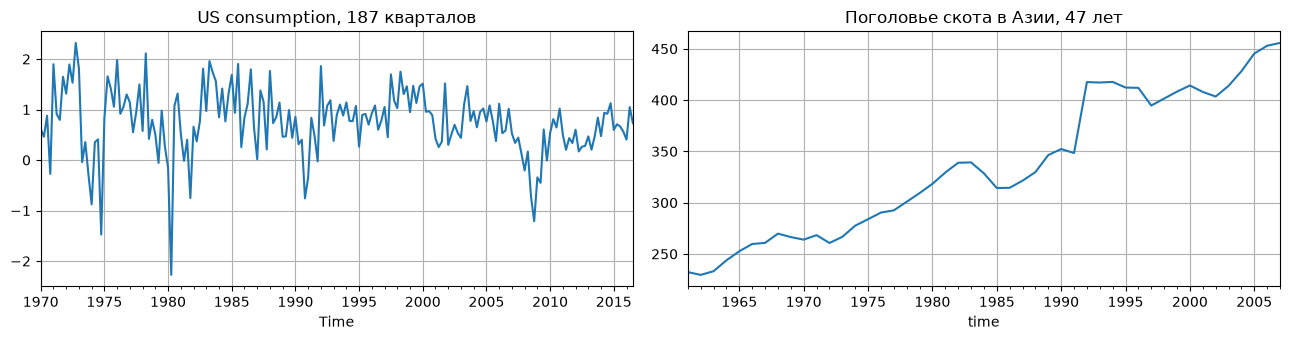

In [4]:
us = pd.read_csv("../data/us_change.csv", parse_dates=["Time"]).set_index("Time")
us.index.freq = "QS"
consumption = us["Consumption"]

livestock = pd.read_csv("../data/livestock.csv")
livestock = pd.Series(
    livestock["value"].to_numpy(),
    index=pd.PeriodIndex(livestock["time"].astype(int), freq="Y").to_timestamp(),
    name="livestock",
)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
consumption.plot(ax=axes[0], title=f"US consumption, {len(consumption)} кварталов")
livestock.plot(ax=axes[1], title=f"Поголовье скота в Азии, {len(livestock)} лет")
fig.tight_layout()
plt.show()

---
# 1. Семь шагов Хайндмана

Существуют два способа изложить идентификацию порядка. Первый — 18 правил
Бокса–Дженкинса (они разобраны в лонгриде). Второй — процедура из семи
шагов, которую предлагает Хайндман. Мы берём вторую как каркас, а правила
подключаем по ходу как комментарии — так меньше запоминать и понятнее,
зачем каждый шаг нужен.

> **Шаг 1. Постройте график ряда.** Ищите: выбросы, разрывы уровня,
> меняющуюся дисперсию, участки с явно другим поведением. Часть из них
> лечится не моделью, а руками (см. правило 18 в ноутбуке `1.03`).
>
> **Шаг 2. При необходимости сделайте преобразование Бокса–Кокса**, чтобы
> стабилизировать дисперсию (правило 15, ноутбук `1.03`).
>
> **Шаг 3. Если ряд нестационарен — берите разности**, пока не станет
> стационарным. Это даёт $d$ (ноутбук `1.03`, раздел 7).
>
> **Шаг 4. Посмотрите на ACF и PACF разностей.** Похоже на AR($p$)?
> На MA($q$)? Это даёт **стартовые** значения $p$ и $q$.
>
> **Шаг 5. Подгоните модель-кандидата и её ближайших соседей**, сравните по
> AICc, выберите лучшую.
>
> **Шаг 6. Проверьте остатки** на ACF, нормальность и автокорреляцию.
> Если остатки не похожи на белый шум — **вернитесь к шагу 4**.
>
> **Шаг 7. Когда остатки похожи на белый шум — стройте прогноз.**

## 1.1. Что здесь важно

Три вещи, которые легко потерять из виду.

**Первое: шаги 3 и 5 разделены не случайно.** $d$ выбирается **тестами и
графиками**, а не по AICc. Причина техническая, но железная: при разном $d$
правдоподобия несопоставимы (раздел 5.4), поэтому AICc просто не может
сравнить $d = 0$ и $d = 1$. Никакой перебор по трём индексам сразу
невозможен — сначала $d$, потом $(p, q)$.

**Второе: шаг 6 — это цикл, а не проверка галочкой.** Стрелка «вернитесь к
шагу 4» и есть суть процедуры: идентификация итеративна.

**Третье: между шагами 4 и 5 распределение труда такое.** ACF/PACF дают
*грубую* подсказку (порядок величины, «скорее AR, чем MA»), AICc *уточняет*.
Полагаться только на ACF нельзя — она врёт на смешанных моделях; полагаться
только на AICc тоже нельзя — он выберет что-нибудь бессмысленное, если сетка
перебора не ограничена здравым смыслом.

## 1.2. Автоматическая версия — три шага

`AutoARIMA` из `statsforecast` (и `auto.arima` в R) делает то же самое, но
короче:

1. выбрать $d$ по тесту на единичный корень (KPSS);
2. перебрать $(p, q)$ по минимуму AICc пошаговым обходом;
3. проверить остатки.

Пропали шаги 1, 2 и 7 — то есть **всё, что требует глаз**: график, выбор
преобразования и решение о том, годится ли прогноз. Это ровно та граница,
где автоматика заканчивается.

Схематично процедура выглядит так:

```
          ┌──────────────────────┐
          │ 1. график ряда       │
          └──────────┬───────────┘
                     v
          ┌──────────────────────┐
          │ 2. Бокс–Кокс?        │   дисперсия
          └──────────┬───────────┘
                     v
          ┌──────────────────────┐
          │ 3. разности -> d     │   уровень (KPSS/ADF)
          └──────────┬───────────┘
                     v
          ┌──────────────────────┐
          │ 4. ACF/PACF -> p, q  │ <─────────────┐
          └──────────┬───────────┘               │
                     v                           │
          ┌──────────────────────┐               │
          │ 5. кандидаты, AICc   │               │
          └──────────┬───────────┘               │
                     v                           │
          ┌──────────────────────┐   плохие      │
          │ 6. остатки = ШУМ?    │───────────────┘
          └──────────┬───────────┘
                     v хорошие
          ┌──────────────────────┐
          │ 7. прогноз           │
          └──────────────────────┘
```

Шаги 1–3 разобраны в семинаре 1. Этот ноутбук — про шаги 4–7.

---
# 2. Шпаргалка: ACF и PACF основных процессов

Шаг 4 целиком держится на двух правилах (правила 6 и 7 лонгрида):

> **Правило 6.** ACF **обрывается** после лага $q$, PACF затухает
> $\Rightarrow$ это **MA($q$)**.
>
> **Правило 7.** PACF **обрывается** после лага $p$, ACF затухает
> $\Rightarrow$ это **AR($p$)**.
>
> **Ни то, ни другое не обрывается** $\Rightarrow$ это **ARMA**, и порядок по
> коррелограммам не читается — нужен AICc.

«Обрывается» (cuts off) — резко падает до незначимых значений и там остаётся.
«Затухает» (tails off) — убывает постепенно, геометрически или волнообразно.

Соберём все случаи на одной картинке — эту сетку удобно держать перед
глазами при разборе реальных рядов.

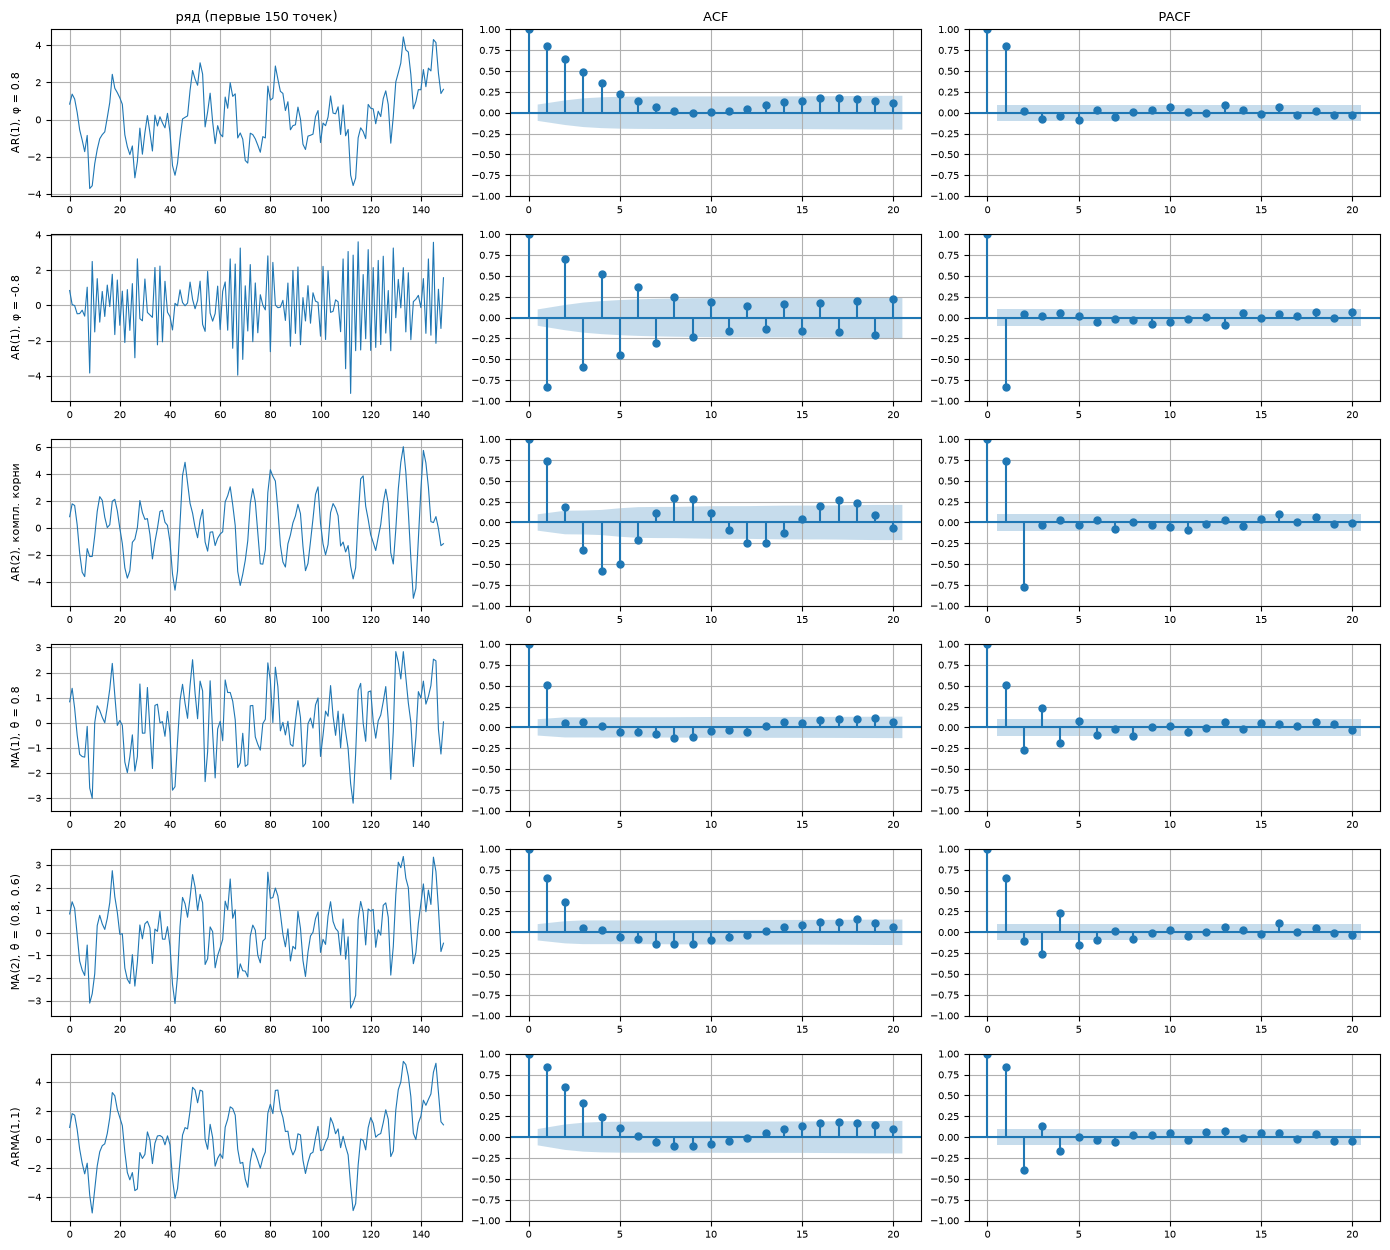

In [5]:
def simulate(ar=(), ma=(), n=400, seed=SEED):
    """Симуляция ARMA. ar/ma задаются в 'человеческих' знаках: y_t = phi*y_{t-1} + ...

    ArmaProcess.from_coeffs сама переворачивает знаки AR-части,
    так что о соглашении statsmodels (ноутбук 01, раздел 0.3) думать не нужно.
    """
    gen = np.random.default_rng(seed)
    proc = ArmaProcess.from_coeffs(list(ar), list(ma))
    return proc.generate_sample(n, distrvs=gen.standard_normal)


ZOO = [
    ("AR(1), φ = 0.8",       dict(ar=(0.8,))),
    ("AR(1), φ = -0.8",      dict(ar=(-0.8,))),
    ("AR(2), компл. корни",  dict(ar=(1.3, -0.8))),
    ("MA(1), θ = 0.8",       dict(ma=(0.8,))),
    ("MA(2), θ = (0.8, 0.6)", dict(ma=(0.8, 0.6))),
    ("ARMA(1,1)",            dict(ar=(0.7,), ma=(0.6,))),
]

fig, axes = plt.subplots(len(ZOO), 3, figsize=(14, 2.1 * len(ZOO)))
for row, (name, kwargs) in enumerate(ZOO):
    y = simulate(**kwargs)
    axes[row, 0].plot(y[:150], lw=0.8)
    axes[row, 0].set_ylabel(name, fontsize=8)
    plot_acf(y, lags=20, ax=axes[row, 1], title="")
    plot_pacf(y, lags=20, ax=axes[row, 2], method="ywm", title="")
    for col in range(3):
        axes[row, col].tick_params(labelsize=7)

axes[0, 0].set_title("ряд (первые 150 точек)", fontsize=9)
axes[0, 1].set_title("ACF", fontsize=9)
axes[0, 2].set_title("PACF", fontsize=9)
fig.tight_layout()
plt.show()

Читаем сетку строка за строкой:

| Строка | ACF | PACF | Вывод |
|---|---|---|---|
| AR(1), $\varphi = 0.8$ | плавно затухает | обрыв после лага 1 | AR(1) |
| AR(1), $\varphi = -0.8$ | затухает **со сменой знака** | обрыв после лага 1 | AR(1) |
| AR(2), компл. корни | затухающая **волна** | обрыв после лага 2 | AR(2) |
| MA(1) | обрыв после лага 1 | затухает со сменой знака | MA(1) |
| MA(2) | обрыв после лага 2 | затухает | MA(2) |
| ARMA(1,1) | затухает | затухает | ARMA, порядок не читается |

🔑 **Симметрия, которую стоит запомнить.** У AR обрывается PACF, у MA — ACF.
Ровно наоборот тому, что подсказывает интуиция «ACF для AR», и ровно поэтому
их путают на экзамене. Мнемоника: **AR ↔ PACF** (обе аббревиатуры с «A»
внутри слова *партиальная*… не работает; проще запомнить, что буквы
«перекрещиваются»: A**R** ↔ **P**ACF, **M**A ↔ **A**CF).

🔍 **Знак коэффициента виден по чередованию.** Отрицательный $\varphi$ у AR
даёт ACF, скачущую между плюсом и минусом; положительный — плавно
затухающую. То же и с $\theta$ для PACF у MA. Это бесплатная информация:
ещё до подгонки понятно, какого знака будут коэффициенты.

## 2.1. Почему ARMA не читается — и что с этим делать

Последняя строка — самая практически важная. У ARMA(1,1) обе функции
затухают, и по картинке нельзя сказать, где $p$, а где $q$. Хуже того:
коррелограмма ARMA(1,1) выглядит почти как у AR(1) с другим $\varphi$.

Отсюда рабочая стратегия шага 4:

* если **одна** из функций явно обрывается — берём чистую AR или MA-модель,
  это надёжная идентификация;
* если **обе** затухают — начинаем с малых порядков вроде ARMA(1,1) и
  уточняем перебором по AICc (раздел 5).

🔍 Не пытайтесь «увидеть» ARMA(2,3) на коррелограмме — этого не умеет никто.

---
# 3. PACF: что это вообще такое

Мы рисуем PACF с первого ноутбука семинара, но ни разу не сказали, что это
за число. Пора: без этого правило 7 остаётся заклинанием.

## 3.1. Определение через регрессию

**Частная автокорреляция** $\alpha_k$ — это коэффициент при **последнем**
лаге в регрессии ряда на первые $k$ своих лагов:

$$ y_t = c + \beta_1 y_{t-1} + \beta_2 y_{t-2} + \dots + \beta_k y_{t-k}
   + u_t, \qquad \alpha_k := \beta_k. $$

Смысл: $\alpha_k$ измеряет связь $y_t$ и $y_{t-k}$, **из которой убрано всё,
что объясняется промежуточными лагами** $y_{t-1}, \dots, y_{t-k+1}$.

Сравните с обычной ACF: $\rho_2$ у AR(1) не равна нулю просто потому, что
$y_t$ связан с $y_{t-1}$, а $y_{t-1}$ — с $y_{t-2}$. Это «связь по цепочке»,
а не прямое влияние. PACF цепочку разрывает — и у AR(1) даёт ноль на всех
лагах, кроме первого. Вот откуда правило 7.

Посчитаем PACF по определению — циклом обычных OLS-регрессий.

In [6]:
def pacf_manual(y, nlags=10):
    """PACF по определению: коэффициент при последнем лаге в регрессии на k лагов."""
    y = np.asarray(y, dtype=float)
    out = [1.0]                                  # alpha_0 = 1 по соглашению
    for k in range(1, nlags + 1):
        target = y[k:]                           # y_t
        lags = np.column_stack(                  # y_{t-1}, ..., y_{t-k}
            [y[k - j: len(y) - j] for j in range(1, k + 1)]
        )
        beta = sm.OLS(target, sm.add_constant(lags)).fit().params
        out.append(beta[-1])                     # коэффициент при y_{t-k}
    return np.array(out)


y_ar2 = simulate(ar=(0.6, -0.3), n=300)

manual = pacf_manual(y_ar2, nlags=8)
library = pacf(y_ar2, nlags=8, method="ols")

pd.DataFrame({
    "руками (цикл OLS)": manual,
    "statsmodels, method='ols'": library,
    "разница": manual - library,
}, index=pd.Index(range(9), name="лаг k")).round(10)

,руками (цикл OLS),"statsmodels, method='ols'",разница
лаг k,,,
0,1.000000,1.000000,0.0
1,0.457911,0.457911,-0.0
2,-0.287189,-0.287189,-0.0
3,-0.028313,-0.028313,-0.0
4,-0.003052,-0.003052,-0.0
5,-0.044873,-0.044873,-0.0
6,0.009618,0.009618,0.0
7,-0.109943,-0.109943,-0.0
8,-0.052294,-0.052294,-0.0


Совпадение до машинной точности: `pacf(..., method='ols')` — это буквально
наш цикл.




## 3.2. То же самое через остатки

Есть второе, эквивалентное определение, которое лучше объясняет слово
«частная». Чтобы измерить связь $y_t$ и $y_{t-k}$ без посредников:

1. вычтем из $y_t$ то, что объясняется промежуточными лагами $\Rightarrow$
   остаток $u_t$;
2. вычтем то же самое из $y_{t-k}$ $\Rightarrow$ остаток $v_t$;
3. посчитаем обычную корреляцию $u$ и $v$.

То, что осталось после вычитания посредников, — и есть «чистая» связь.

In [7]:
def pacf_via_residuals(y, k):
    """alpha_k как корреляция остатков y_t и y_{t-k} после очистки от промежуточных лагов."""
    y = np.asarray(y, dtype=float)
    if k == 1:
        return np.corrcoef(y[1:], y[:-1])[0, 1]

    middle = np.column_stack([y[k - j: len(y) - j] for j in range(1, k)])
    X = sm.add_constant(middle)

    target, far = y[k:], y[: len(y) - k]
    u = target - sm.OLS(target, X).fit().fittedvalues     # y_t без посредников
    v = far - sm.OLS(far, X).fit().fittedvalues           # y_{t-k} без посредников
    return np.corrcoef(u, v)[0, 1]


pd.DataFrame({
    "через остатки": [pacf_via_residuals(y_ar2, k) for k in range(1, 7)],
    "через регрессию": pacf_manual(y_ar2, nlags=6)[1:],
}, index=pd.Index(range(1, 7), name="лаг k")).round(5)

,через остатки,через регрессию
лаг k,,
1,0.45816,0.45791
2,-0.28743,-0.28719
3,-0.02827,-0.02831
4,-0.00305,-0.00305
5,-0.04488,-0.04487
6,0.00963,0.00962


🔍 Числа совпадают в третьем-четвёртом знаке, но не идеально. Это не ошибка:
коэффициент регрессии — это $\mathrm{cov}(u, v) / \mathrm{Var}(v)$, а
корреляция — $\mathrm{cov}(u, v) / (\sigma_u \sigma_v)$. У стационарного ряда
$\sigma_u \approx \sigma_v$, поэтому в генеральной совокупности они равны, а
на конечной выборке — почти равны. Обе величины называются PACF.

## 3.3. Границы значимости и почему их нельзя читать буквально

Синяя полоса на графиках ACF/PACF — это $\pm 1.96 / \sqrt{n}$. Откуда она:
если ряд на самом деле белый шум, то выборочные $\hat\rho_k$ и
$\hat\alpha_k$ приблизительно нормальны со стандартным отклонением
$1/\sqrt{n}$. Значит, отдельный столбик выходит за полосу примерно в **5%
случаев чисто случайно**.

Теперь считаем. Если вы смотрите на 36 лагов, то ожидаемое число ложных
«значимых» столбиков равно $36 \times 0.05 \approx 1.8$. То есть **один-два
выброса за полосу на коррелограмме белого шума — норма, а не сигнал.**

Проверим это симуляцией: 500 раз сгенерируем белый шум и посмотрим, сколько
столбиков вылезло за границы.

граница ±1.96/sqrt(n) = ±0.139
среднее число 'значимых' лагов у БЕЛОГО ШУМА: 1.37 из 36
хотя бы один выброс:      72.6% симуляций
три и более выбросов:     16.8% симуляций


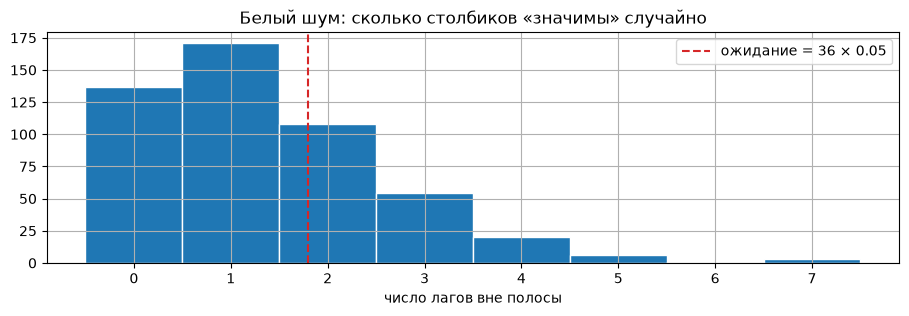

In [8]:
n, n_lags, n_rep = 200, 36, 500
gen = np.random.default_rng(SEED)
bound = 1.96 / np.sqrt(n)

counts = []
for _ in range(n_rep):
    noise = gen.standard_normal(n)
    counts.append(int((np.abs(acf(noise, nlags=n_lags)[1:]) > bound).sum()))

counts = np.array(counts)
print(f"граница ±1.96/sqrt(n) = ±{bound:.3f}")
print(f"среднее число 'значимых' лагов у БЕЛОГО ШУМА: {counts.mean():.2f} из {n_lags}")
print(f"хотя бы один выброс:      {(counts >= 1).mean():.1%} симуляций")
print(f"три и более выбросов:     {(counts >= 3).mean():.1%} симуляций")

fig, ax = plt.subplots(figsize=(11, 3))
ax.hist(counts, bins=np.arange(-0.5, counts.max() + 1.5), edgecolor="w")
ax.axvline(n_lags * 0.05, color="tab:red", ls="--", label="ожидание = 36 × 0.05")
ax.set_xlabel("число лагов вне полосы"); ax.set_title("Белый шум: сколько столбиков «значимы» случайно")
ax.legend()
plt.show()

🔑 **Вывод для чтения коррелограмм.** Значимость отдельного столбика на
далёком лаге — это почти всегда шум. Доверять стоит:

* **первым нескольким лагам** (их вы проверяете не «заодно», а прицельно);
* **систематическому узору** — затуханию, чередованию знаков, всплеску на
  лаге, равном периоду сезонности;
* **portmanteau-тесту**, который проверяет все лаги сразу и учитывает
  множественность (ноутбук `1.01`, раздел 7). К нему вернёмся в разделе 7.

Одиночный столбик на лаге 17 не означает, что нужно ставить $q = 17$.

---
# 4. Упражнение «определи порядок вслепую»

Теория закончилась, попробуйте сами. Ниже шесть симулированных рядов по
300 наблюдений. Порядки известны генератору, но не вам.

**Задача.** Для каждого ряда по панели «ряд + ACF + PACF» назвать $(p, d, q)$.

**Как действовать:**

1. посмотреть на сам ряд: есть ли тренд, блуждает ли уровень $\Rightarrow$
   нужна ли разность ($d$);
2. если ACF затухает **очень медленно и вся положительная** — это
   нестационарность, берите разность и смотрите заново (правило 1);
3. обрыв ACF на лаге $q$ $\Rightarrow$ MA($q$); обрыв PACF на лаге $p$
   $\Rightarrow$ AR($p$); ничего не обрывается $\Rightarrow$ ARMA.

Ответы — в конце ноутбука, под спойлером «Ответы к разделу 4». Не
подсматривайте сразу: смысл упражнения в том, чтобы сначала ошибиться.

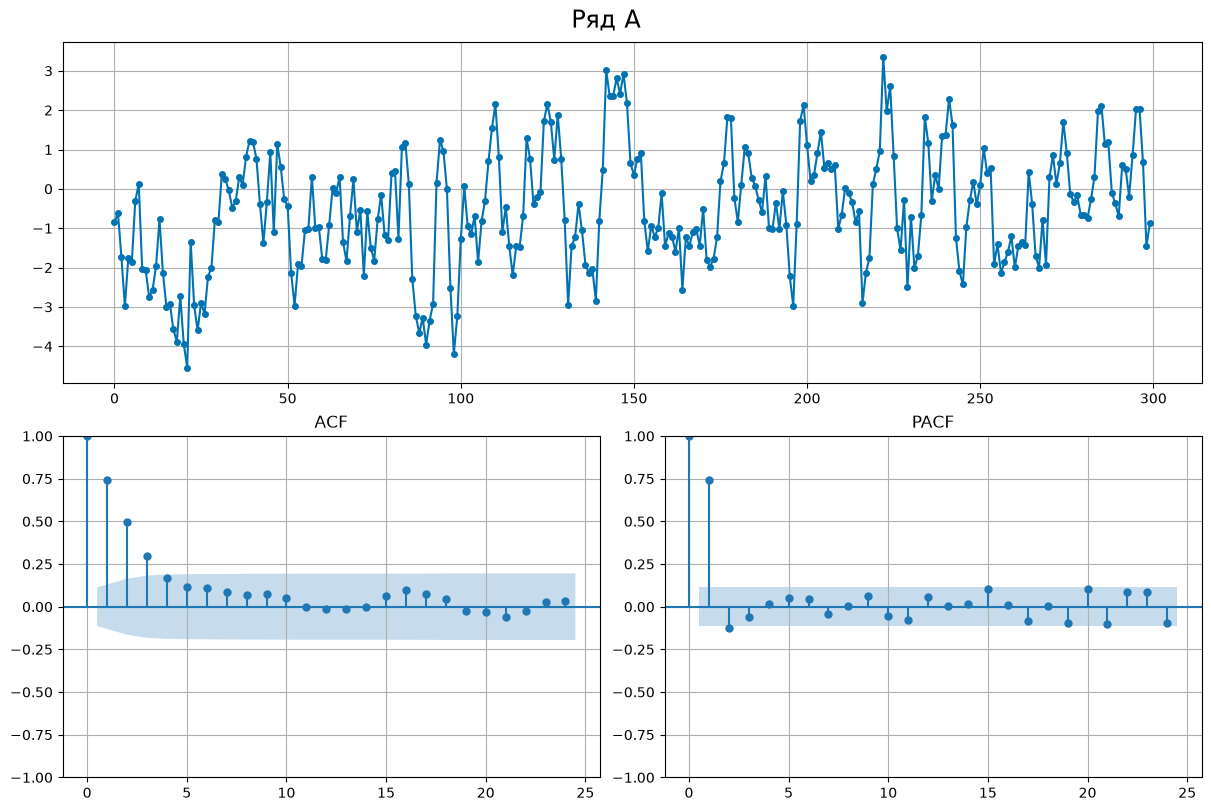

<Figure size 1300x600 with 0 Axes>

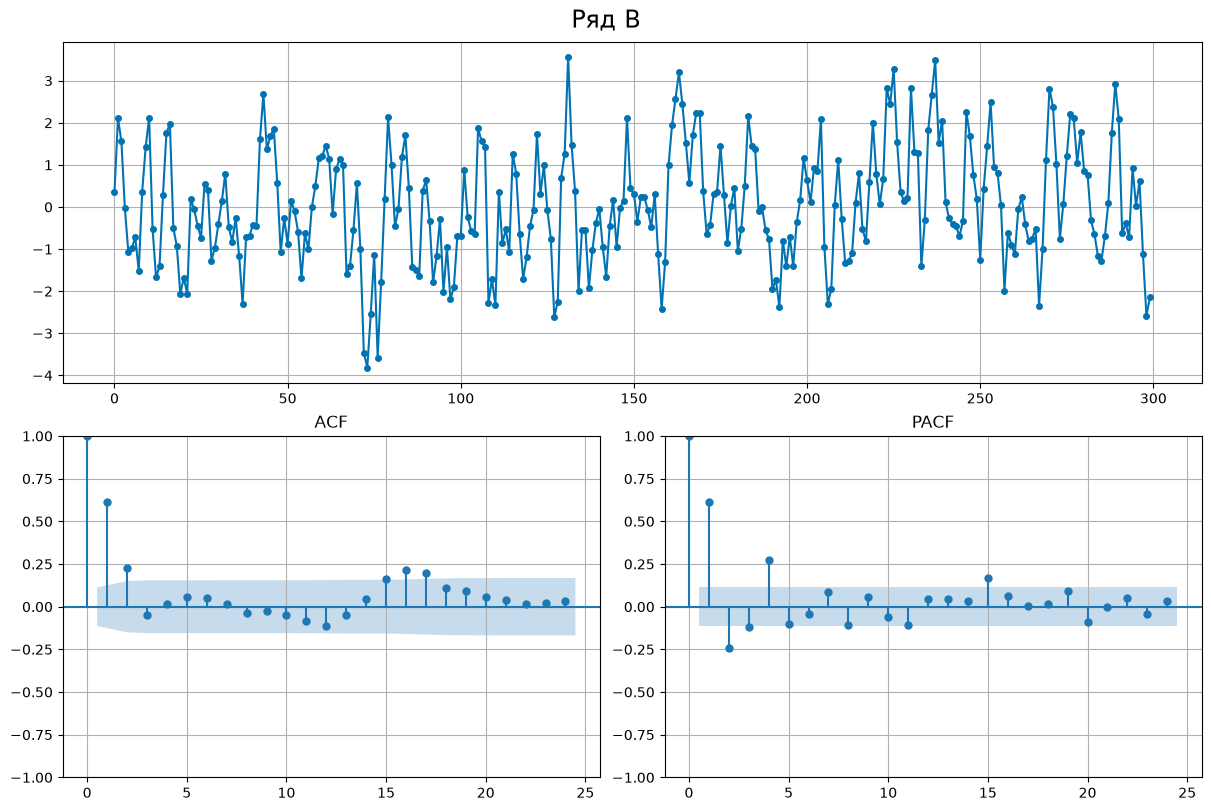

<Figure size 1300x600 with 0 Axes>

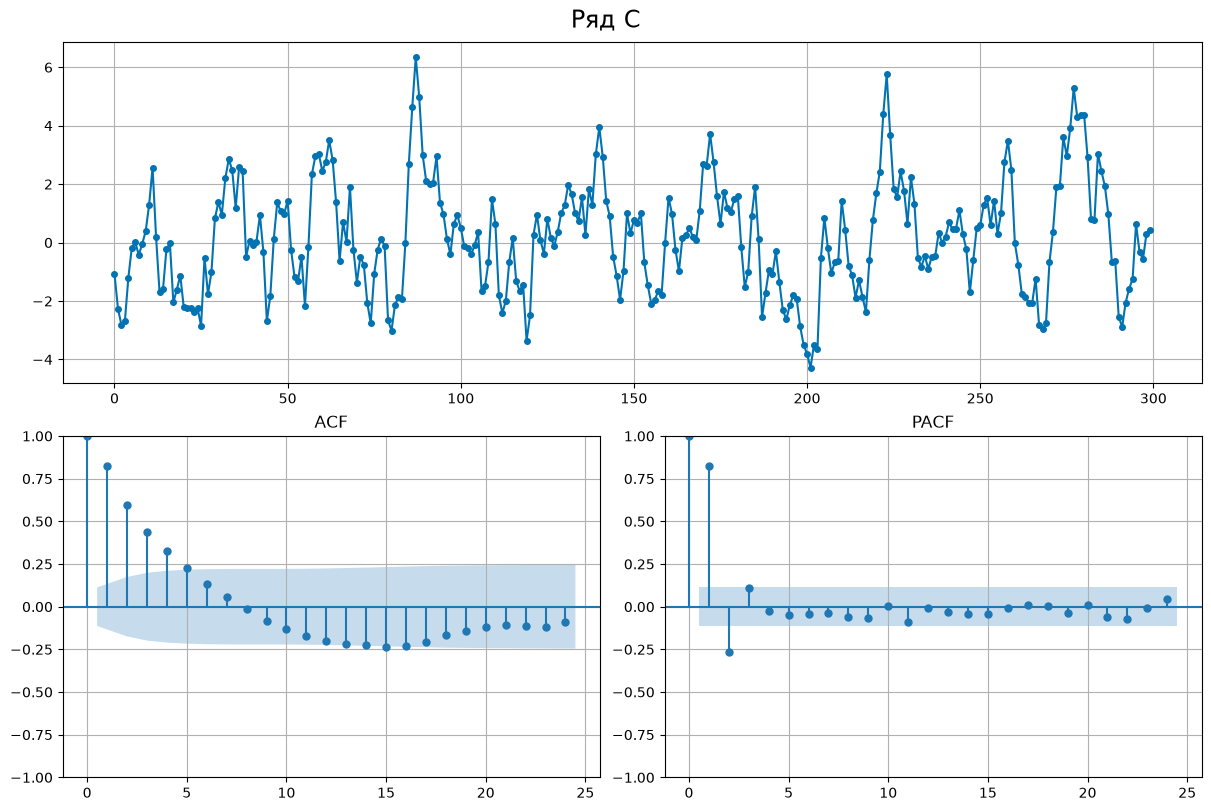

<Figure size 1300x600 with 0 Axes>

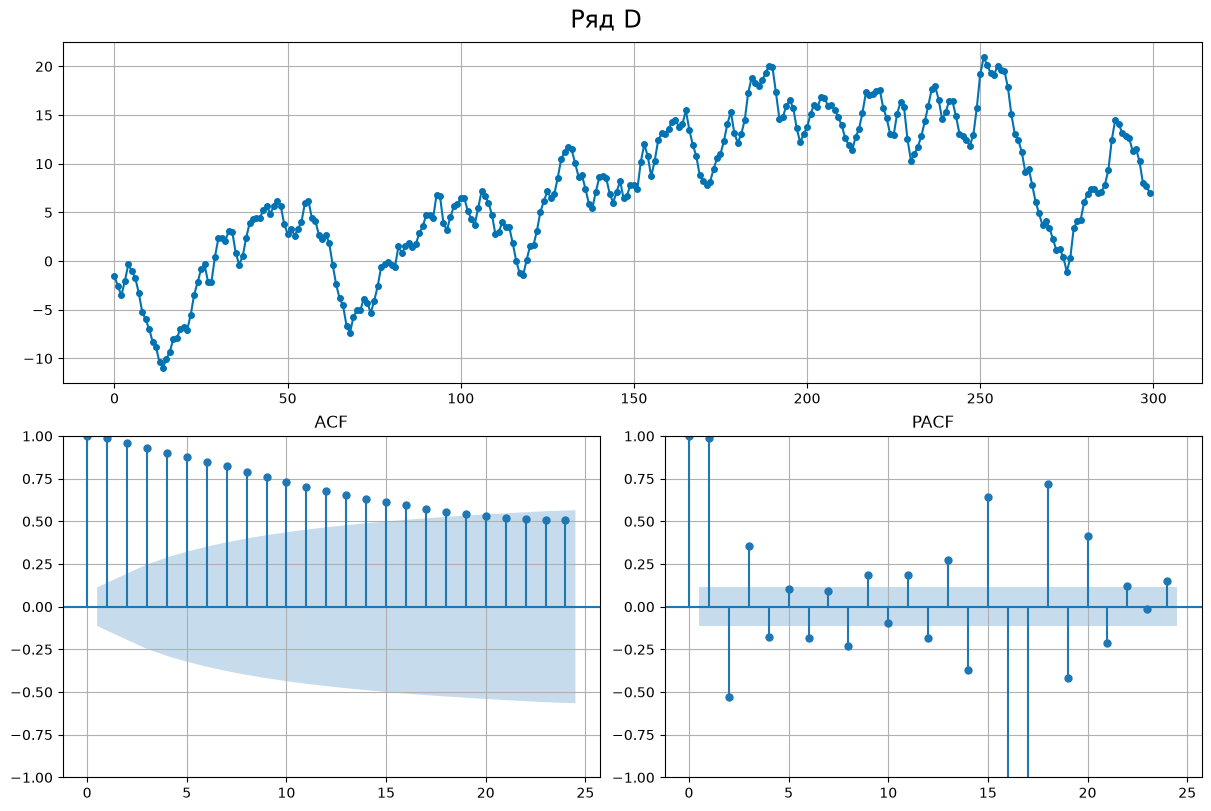

<Figure size 1300x600 with 0 Axes>

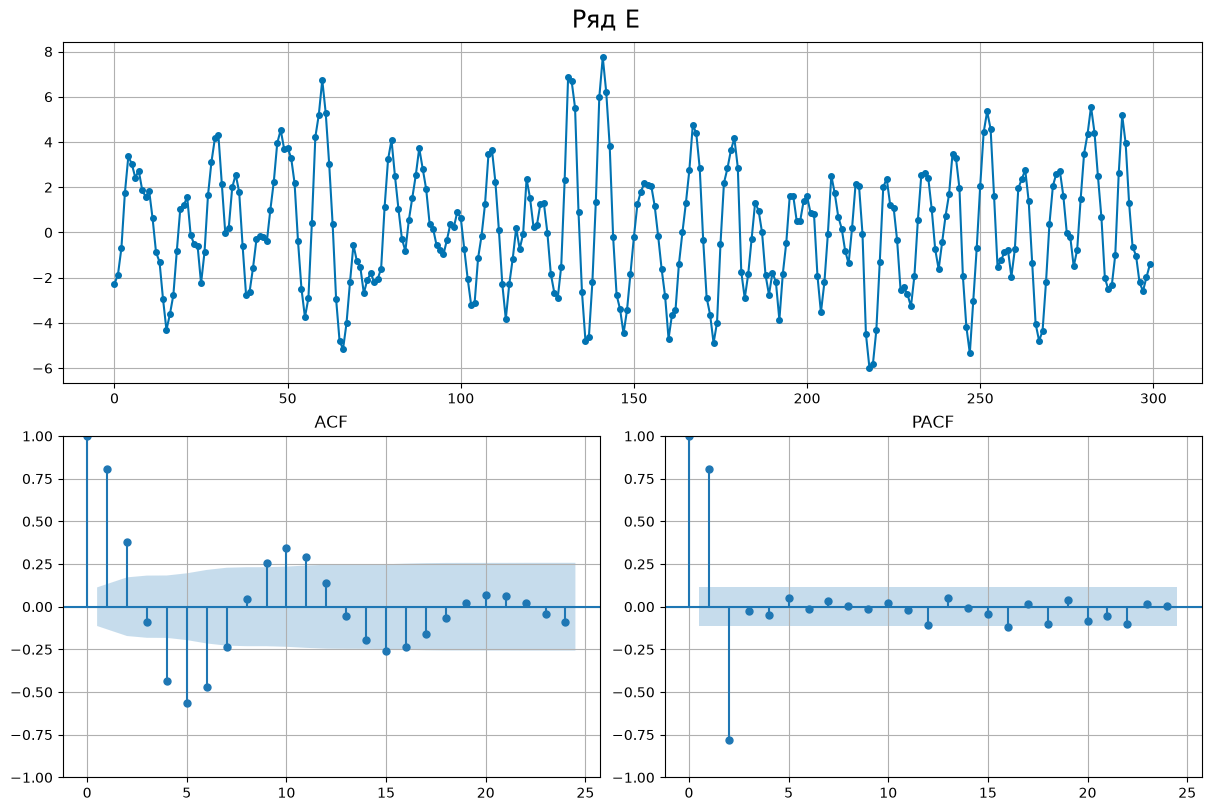

<Figure size 1300x600 with 0 Axes>

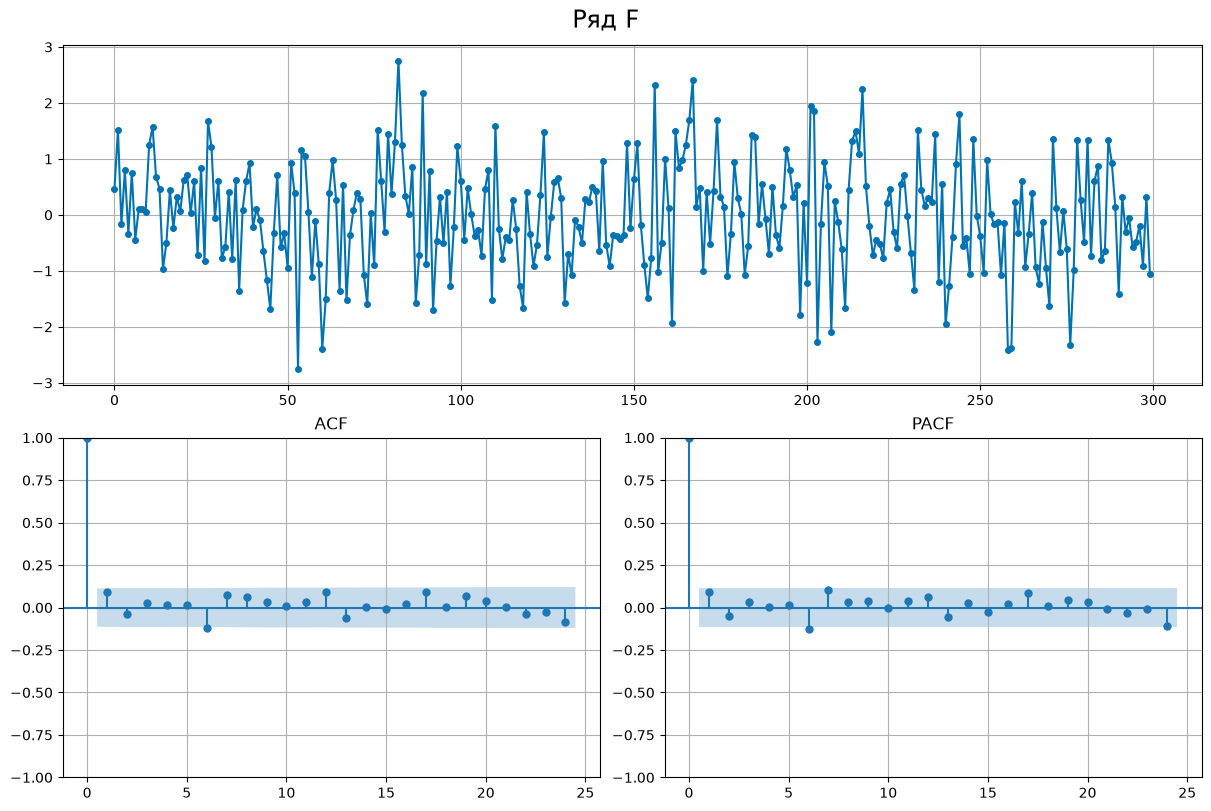

<Figure size 1300x600 with 0 Axes>

In [10]:
QUIZ_SEED = 777


def make_quiz():
    """Шесть рядов с известными (но спрятанными) порядками."""
    gen = np.random.default_rng(QUIZ_SEED)
    specs = [
        ((0.8,), (), 0),          # A
        ((), (0.9, 0.6), 0),      # B
        ((0.6,), (0.5,), 0),      # C
        ((), (0.7,), 1),          # D
        ((1.4, -0.75), (), 0),    # E
        ((), (), 0),              # F
    ]
    series, truth = {}, {}
    for letter, (ar, ma, d) in zip("ABCDEF", specs):
        proc = ArmaProcess.from_coeffs(list(ar), list(ma))
        y = proc.generate_sample(300, distrvs=gen.standard_normal)
        for _ in range(d):                       # интегрируем нужное число раз
            y = np.cumsum(y)
        series[letter] = y
        truth[letter] = (len(ar), d, len(ma))
    return series, truth


quiz, quiz_truth = make_quiz()

for letter in "ABCDEF":
    tsdisplay(pd.Series(quiz[letter]), lags=24, title=f"Ряд {letter}")
    plt.show()

Запишите свои шесть ответов на бумажке.

Теперь — как бы на это посмотрел автоподбор. Прогоняем `AutoARIMA` из
`statsforecast`: он делает то же самое, что вы, только формально (KPSS для
$d$, AICc для $p, q$).

🔍 `season_length=1` означает «сезонности нет» — сегодня мы работаем только с
несезонными моделями, сезонная часть будет в семинаре 5.

In [11]:
from statsforecast.models import AutoARIMA
from statsforecast.arima import arima_string

auto_answers = {}
for letter in "ABCDEF":
    model = AutoARIMA(season_length=1).fit(np.asarray(quiz[letter], dtype=np.float64))
    auto_answers[letter] = arima_string(model.model_).strip()

pd.DataFrame({"AutoARIMA говорит": auto_answers})

,AutoARIMA говорит
A,"ARIMA(1,1,1) with drift"
B,"ARIMA(0,1,0)"
C,"ARIMA(4,0,1) with non-zero mean"
D,"ARIMA(0,1,1)"
E,"ARIMA(2,0,0) with zero mean"
F,"ARIMA(0,0,0) with zero mean"


Сверьте с тем, что написали вы. Если совпало не всё — это нормально; ниже
(раздел 8) выяснится, что и сама «истина» бывает не единственной. Ответы
генератора — в конце ноутбука.

---
# 5. Информационные критерии

Шаг 4 дал стартовое приближение. Шаг 5 — уточнение перебором.

## 5.1. Зачем нужен критерий

Казалось бы, выбирать модель просто: у какой правдоподобие выше, та и лучше.
Не работает. **Правдоподобие всегда растёт при добавлении параметров** —
ARMA(5,5) подгонится к данным лучше, чем ARMA(1,1), даже если истина
ARMA(1,1). Это переобучение: модель начинает описывать шум конкретной
выборки.

Информационный критерий = «минус правдоподобие + штраф за сложность»:

$$ \mathrm{AIC} = -2\ln L + 2k, \qquad
   \mathrm{AICc} = \mathrm{AIC} + \frac{2k(k+1)}{n-k-1}, \qquad
   \mathrm{BIC} = -2\ln L + k \ln n. $$

Меньше — лучше. Разница между ними — **только в силе штрафа**:

| Критерий | Штраф за параметр | Что делает |
|---|---|---|
| AIC | $2$ | ищет модель с лучшим прогнозом; на коротких рядах переусложняет |
| AICc | $2 + $ поправка | то же, но честно на конечной выборке; **рекомендация лекции** |
| BIC | $\ln n$ (при $n > 7$ это $> 2$) | ищет «истинную» модель; систематически проще |

🔍 При $n = 187$ штраф BIC равен $\ln 187 \approx 5.2$ против $2$ у AIC —
в два с половиной раза строже. Поэтому BIC почти всегда выбирает более
скромную модель.

In [12]:
for n_ in [20, 50, 187, 1000]:
    print(f"n = {n_:>4}:  штраф AIC = 2.00,  штраф BIC = ln(n) = {np.log(n_):.2f}")

n =   20:  штраф AIC = 2.00,  штраф BIC = ln(n) = 3.00
n =   50:  штраф AIC = 2.00,  штраф BIC = ln(n) = 3.91
n =  187:  штраф AIC = 2.00,  штраф BIC = ln(n) = 5.23
n = 1000:  штраф AIC = 2.00,  штраф BIC = ln(n) = 6.91


## 5.2. Перебор по сетке: heatmap

Возьмём ряд поголовья скота. Из семинара 1 мы знаем процедуру выбора $d$;
повторим её коротко, чтобы зафиксировать $d$ перед перебором.

KPSS на уровне:   p-value = 0.010  -> нестационарен
KPSS на разности: p-value = 0.100  -> стационарен

вывод: d = 1


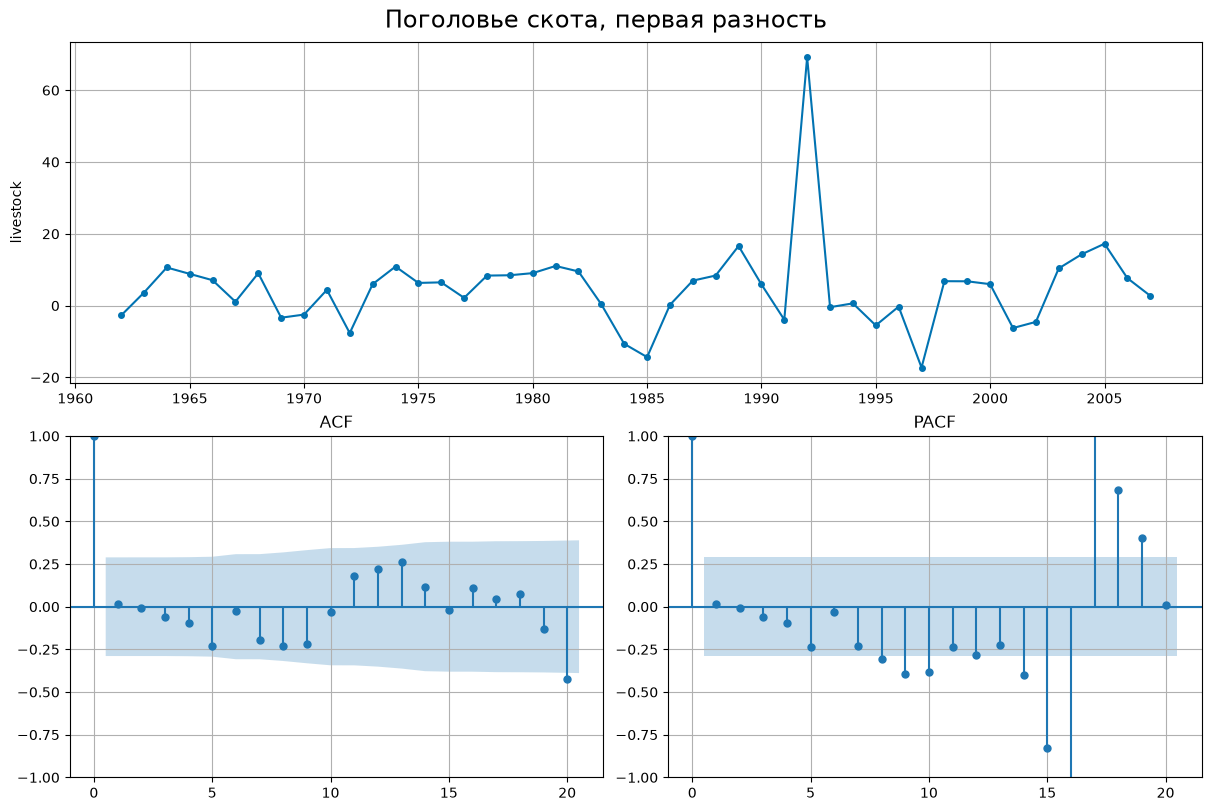

<Figure size 1300x600 with 0 Axes>

In [13]:
stat_kpss = kpss(livestock, regression="c", nlags="auto")
stat_kpss_d1 = kpss(livestock.diff().dropna(), regression="c", nlags="auto")

print(f"KPSS на уровне:   p-value = {stat_kpss[1]:.3f}  -> {'нестационарен' if stat_kpss[1] < 0.05 else 'стационарен'}")
print(f"KPSS на разности: p-value = {stat_kpss_d1[1]:.3f}  -> {'нестационарен' if stat_kpss_d1[1] < 0.05 else 'стационарен'}")
print("\nвывод: d = 1")

tsdisplay(livestock.diff().dropna(), lags=20, title="Поголовье скота, первая разность")
plt.show()

По коррелограмме разности: ни ACF, ни PACF не показывают ничего
выразительного — почти все столбики внутри полосы. Это само по себе ответ:
**разность похожа на белый шум**, то есть кандидат номер один — ARIMA(0,1,0),
случайное блуждание.

Но проверим перебором. Строим сетку $p, q \in \{0, 1, 2, 3\}$ при $d = 1$ и
считаем все три критерия.

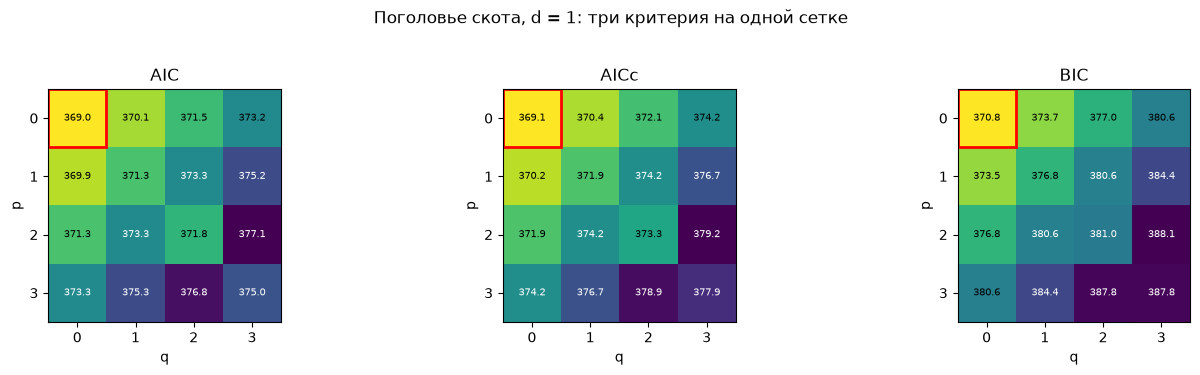

,order,k,n,AIC,AICc,BIC,p,q
0,"(0, 1, 0)",1,47,369.01,369.10,370.84,0,0
4,"(1, 1, 0)",2,47,369.88,370.16,373.54,1,0
1,"(0, 1, 1)",2,47,370.09,370.36,373.74,0,1
5,"(1, 1, 1)",3,47,371.35,371.90,376.83,1,1
8,"(2, 1, 0)",3,47,371.35,371.91,376.83,2,0
2,"(0, 1, 2)",3,47,371.54,372.10,377.03,0,2


In [14]:
P_MAX, Q_MAX = 3, 3

rows = []
for p in range(P_MAX + 1):
    for q in range(Q_MAX + 1):
        try:
            rows.append(fit_report(livestock, (p, 1, q), trend="n"))
        except Exception as err:
            rows.append({"order": f"({p}, 1, {q})", "k": np.nan, "n": np.nan,
                         "AIC": np.nan, "AICc": np.nan, "BIC": np.nan})

grid = pd.DataFrame(rows)
grid[["p", "q"]] = [(int(s[1]), int(s[-2])) for s in grid["order"]]

heat = {crit: grid.pivot(index="p", columns="q", values=crit) for crit in ("AIC", "AICc", "BIC")}

fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
for ax, (crit, table) in zip(axes, heat.items()):
    im = ax.imshow(table.to_numpy(), cmap="viridis_r")
    ax.set_xticks(range(Q_MAX + 1)); ax.set_yticks(range(P_MAX + 1))
    ax.set_xlabel("q"); ax.set_ylabel("p"); ax.set_title(crit)
    ax.grid(False)
    best = np.unravel_index(np.nanargmin(table.to_numpy()), table.shape)
    for i in range(P_MAX + 1):
        for j in range(Q_MAX + 1):
            val = table.to_numpy()[i, j]
            ax.text(j, i, f"{val:.1f}", ha="center", va="center", fontsize=7,
                    color="w" if val > np.nanmedian(table.to_numpy()) else "k")
    ax.add_patch(plt.Rectangle((best[1] - .5, best[0] - .5), 1, 1, fill=False, ec="red", lw=2))
fig.suptitle("Поголовье скота, d = 1: три критерия на одной сетке", y=1.03)
fig.tight_layout()
plt.show()

grid.sort_values("AICc").head(6).round(2)

Все три критерия согласны: лучшая модель — **ARIMA(0,1,0)**, то есть
наивный прогноз «завтра как сегодня». Догадка по коррелограмме подтвердилась.

🔍 Обратите внимание на разброс AICc в верхних строках таблицы: между первой
и третьей моделью разница около 1.3. Что это значит — в разделе 6.3.

## 5.3. Где AIC и BIC расходятся

На таком коротком ряду критерии согласны просто потому, что победила самая
простая модель. Возьмём ряд подлиннее — US consumption, где $d = 0$.

In [15]:
rows = []
for p in range(5):
    for q in range(5):
        rows.append(fit_report(consumption, (p, 0, q), trend="c"))

grid_us = pd.DataFrame(rows)

best = pd.DataFrame({
    crit: grid_us.sort_values(crit).head(3)["order"].to_numpy()
    for crit in ("AIC", "AICc", "BIC")
}, index=pd.Index([1, 2, 3], name="место"))
best

,AIC,AICc,BIC
место,,,
1,"(3, 0, 0)","(3, 0, 0)","(3, 0, 0)"
2,"(3, 0, 4)","(4, 0, 0)","(1, 0, 1)"
3,"(4, 0, 0)","(1, 0, 3)","(0, 0, 3)"


,AIC,AICc,BIC
место,,,
1,"(3, 0, 0)","(3, 0, 0)","(3, 0, 0)"
2,"(3, 0, 4)","(4, 0, 0)","(1, 0, 1)"
3,"(4, 0, 0)","(1, 0, 3)","(0, 0, 3)"


In [16]:
grid_us.assign(
    dAICc=lambda d: d["AICc"] - d["AICc"].min(),
    dBIC=lambda d: d["BIC"] - d["BIC"].min(),
).sort_values("AICc").head(8)[["order", "k", "AIC", "AICc", "BIC", "dAICc", "dBIC"]].round(2)

,order,k,AIC,AICc,BIC,dAICc,dBIC
15,"(3, 0, 0)",5,340.34,340.67,356.50,0.00,0.00
20,"(4, 0, 0)",6,341.46,341.93,360.85,1.26,4.35
8,"(1, 0, 3)",6,341.61,342.08,361.00,1.41,4.50
19,"(3, 0, 4)",9,341.20,342.21,370.28,1.54,13.78
16,"(3, 0, 1)",6,341.83,342.30,361.22,1.63,4.73
21,"(4, 0, 1)",7,341.78,342.41,364.40,1.74,7.90
12,"(2, 0, 2)",6,342.28,342.75,361.67,2.08,5.18
3,"(0, 0, 3)",5,342.76,343.09,358.91,2.42,2.42


Читаем таблицу:

* **AICc** ставит на первое место ARIMA(3,0,0), но следующие четыре модели
  отстают меньше чем на 1.6 — и это модели совершенно разной конструкции:
  (4,0,0), (1,0,3), (3,0,4), (3,0,1);
* **BIC** тоже выбирает (3,0,0), но на втором месте у него уже (1,0,1) —
  модель с двумя параметрами вместо четырёх. Более сложные варианты он
  отбрасывает жёстче.

🔑 **Критерий — это ранжирование, а не приговор.** Разница в 1–2 единицы
AICc не значит ничего: она меньше, чем случайный разброс самого критерия
на этой выборке.

## 5.4. Оговорка, которая ломает больше всего кода: разные $d$

**AICc нельзя сравнивать у моделей с разным $d$.** Причина простая:
правдоподобие считается по продифференцированному ряду, а в нём при $d = 1$
на одно наблюдение меньше. Мы сравниваем «качество описания» **разных
наборов данных** — это бессмысленно, как сравнивать суммы по разному числу
слагаемых.

In [17]:
comparison = pd.DataFrame([
    fit_report(consumption, (1, 0, 1), trend="c"),
    fit_report(consumption, (1, 1, 1), trend="n"),
    fit_report(consumption, (1, 2, 1), trend="n"),
])
comparison[["order", "n", "k", "AIC", "AICc", "BIC"]].round(2)

,order,n,k,AIC,AICc,BIC
0,"(1, 0, 1)",187,4,343.82,344.04,356.74
1,"(1, 1, 1)",187,3,356.49,356.62,366.17
2,"(1, 2, 1)",187,3,383.60,383.73,393.26


Столбец `n` разный — 187, 186, 185. Формально минимум AICc здесь есть, но
он ничего не значит.

🔍 **Что тогда можно сравнивать у моделей с разным $d$?** Ошибку прогноза на
отложенной выборке — RMSE, MAE, MASE. Она считается на одних и тех же
фактических значениях, и её сравнение корректно всегда, при любых $(p, d, q)$
и даже между ARIMA и ETS. Этим мы и займёмся в разделе 9.

🔑 **Итого разделение труда:** AICc выбирает $(p, q)$ **при фиксированном
$d$**; $d$ выбирается тестами; финальное сравнение разнородных моделей — по
ошибке на тесте.

---
# 6. Правила-предупреждения

Три ситуации, в которых формальный критерий доволен, а модель плоха.

## 6.1. Правило 8: AR и MA взаимно сокращаются

Если в модели есть и AR-, и MA-часть, они могут «съесть» друг друга:
многочлены $\varphi(L)$ и $\theta(L)$ получают почти совпадающий корень, и
он сокращается, как дробь $\frac{(L-a)(\dots)}{(L-a)(\dots)}$. Правдоподобие
при этом не страдает, а вот оценки коэффициентов разваливаются.

Сгенерируем чистый AR(1) и намеренно подгоним к нему ARMA(2,2).

In [18]:
y_ar1 = simulate(ar=(0.7,), n=200, seed=7)

res_over = ARIMA(y_ar1, order=(2, 0, 2), trend="c").fit()
res_true = ARIMA(y_ar1, order=(1, 0, 0), trend="c").fit()

ar_roots = np.roots(np.r_[1.0, -res_over.arparams][::-1])
ma_roots = np.roots(np.r_[1.0, res_over.maparams][::-1])

print("ARMA(2,2), подогнанная к данным AR(1):")
print("  phi   =", np.round(res_over.arparams, 3))
print("  theta =", np.round(res_over.maparams, 3))
print("  корни AR:", np.round(ar_roots, 3))
print("  корни MA:", np.round(ma_roots, 3), "  <- один почти совпадает с AR-корнем")
print("\nстандартные ошибки оценок:")
print(pd.Series(res_over.bse, index=res_over.param_names).round(3).to_string())
print(f"\nAICc  ARMA(2,2) = {aicc(res_over):.2f}")
print(f"AICc  AR(1)     = {aicc(res_true):.2f}   <- проще и лучше")

ARMA(2,2), подогнанная к данным AR(1):
  phi   = [-0.164  0.736]
  theta = [ 0.821 -0.179]
  корни AR: [ 1.283 -1.059]
  корни MA: [ 5.59 -1.  ]   <- один почти совпадает с AR-корнем

стандартные ошибки оценок:
const     0.245
ar.L1     0.079
ar.L2     0.064
ma.L1     2.882
ma.L2     0.509
sigma2    2.097

AICc  ARMA(2,2) = 520.77
AICc  AR(1)     = 519.83   <- проще и лучше


Смотрим на симптомы:

* корень AR и корень MA почти совпали — сокращающаяся пара;
* **стандартные ошибки огромные**: у некоторых коэффициентов они в разы
  больше самих оценок, то есть коэффициенты неотличимы от нуля;
* AICc у правильной AR(1) всё-таки лучше — здесь критерий справился.

🔑 **Правило 8: избегайте моделей, где $p > 0$ и $q > 0$ одновременно, если
от них нет явного выигрыша.** Если видите огромные стандартные ошибки и
близкие корни $\varphi(L)$ и $\theta(L)$ — сокращайте порядок.

## 6.2. Правила 9–11: сумма AR-коэффициентов близка к единице

Второй симптом. Если $\sum \varphi_i \approx 1$, значит $\varphi(1) \approx 0$,
то есть у AR-многочлена есть **почти единичный корень** — модель пытается
описать нестационарность, не имея на это права. Лечится не подбором $p$, а
увеличением $d$.

Возьмём случайное блуждание со сносом и подгоним к нему стационарную AR(2)
с трендом.

In [19]:
gen = np.random.default_rng(11)
y_rw = np.cumsum(0.4 + gen.standard_normal(120)) + 10

res_wrong = ARIMA(y_rw, order=(2, 0, 0), trend="ct").fit()   # стационарная + тренд
res_right = ARIMA(y_rw, order=(0, 1, 0), trend="t").fit()    # d = 1, снос

print(f"сумма phi у ARIMA(2,0,0): {res_wrong.arparams.sum():.4f}  <- почти 1")
print(f"корни AR-многочлена:      {np.round(np.roots(np.r_[1.0, -res_wrong.arparams][::-1]), 3)}")

сумма phi у ARIMA(2,0,0): 0.9417  <- почти 1
корни AR-многочлена:      [-180.101    1.062]


Сумма $\varphi$ равна 0.94, корень лежит почти на единичной окружности.
Формально модель стационарна, фактически — нет. Самый наглядный симптом
видно не в коэффициентах, а в **интервале прогноза**.

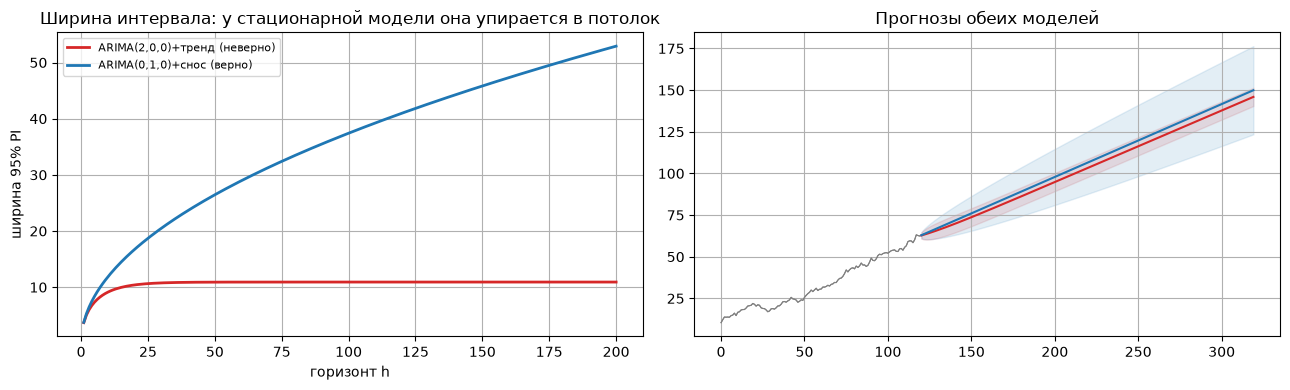

,"ARIMA(2,0,0)+тренд","ARIMA(0,1,0)+снос"
горизонт h,,
1,3.68,3.74
10,9.12,11.83
50,10.90,26.46
200,10.92,52.91


In [20]:
H = 200
hh = np.arange(1, H + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for res_, label, color in [(res_wrong, "ARIMA(2,0,0)+тренд (неверно)", "tab:red"),
                           (res_right, "ARIMA(0,1,0)+снос (верно)", "tab:blue")]:
    fc = res_.get_forecast(H)
    ci = np.asarray(fc.conf_int())
    axes[0].plot(hh, ci[:, 1] - ci[:, 0], color=color, lw=2, label=label)
    axes[1].plot(np.arange(len(y_rw)), y_rw, color="0.5", lw=0.8)
    idx = np.arange(len(y_rw), len(y_rw) + H)
    axes[1].plot(idx, np.asarray(fc.predicted_mean), color=color, lw=1.5)
    axes[1].fill_between(idx, ci[:, 0], ci[:, 1], color=color, alpha=0.12)

axes[0].set_xlabel("горизонт h"); axes[0].set_ylabel("ширина 95% PI")
axes[0].set_title("Ширина интервала: у стационарной модели она упирается в потолок")
axes[0].legend(fontsize=8)
axes[1].set_title("Прогнозы обеих моделей")
fig.tight_layout()
plt.show()

widths = {}
for res_, label in [(res_wrong, "ARIMA(2,0,0)+тренд"), (res_right, "ARIMA(0,1,0)+снос")]:
    ci = np.asarray(res_.get_forecast(H).conf_int())
    widths[label] = (ci[:, 1] - ci[:, 0])[[0, 9, 49, 199]]

pd.DataFrame(widths, index=pd.Index([1, 10, 50, 200], name="горизонт h")).round(2)

Вот она, цена ошибки. У стационарной модели ширина интервала выходит на
потолок (≈11) и дальше не растёт: модель уверена, что ряд вернётся к своему
«среднему». У правильной модели с $d = 1$ ширина продолжает расти как
$\sqrt{h}$ и на горизонте 200 в четыре раза больше (ноутбук `02`, раздел 7).

🔑 **Правила 9–11 одним предложением: если $\sum\varphi_i$ подошла к
единице — не наращивайте $p$, а увеличьте $d$.** Симптомы: неправдоподобно
узкие долгосрочные интервалы или, наоборот, «взорвавшийся» точечный прогноз,
уходящий в бесконечность.

## 6.3. Правило 17: не выбирайте модель по разнице в третьем знаке

Мы уже видели, что несколько моделей стоят в пределах 1–2 AICc друг от
друга. Насколько устойчиво это ранжирование? Проверим: возьмём один и тот же
истинный процесс ARMA(1,1), сгенерируем 200 разных выборок и посмотрим, что
выбирает AICc.

In [21]:
def best_order_by_aicc(y, candidates):
    scores = {}
    for order in candidates:
        try:
            scores[order] = aicc(ARIMA(y, order=order, trend="c").fit())
        except Exception:
            scores[order] = np.inf
    return min(scores, key=scores.get)


CANDIDATES = [(1, 0, 1), (2, 0, 0), (1, 0, 0), (0, 0, 1), (2, 0, 1), (1, 0, 2)]
gen = np.random.default_rng(3)

picks = []
for _ in range(200):
    y_sim = ArmaProcess.from_coeffs([0.7], [0.5]).generate_sample(120, distrvs=gen.standard_normal)
    picks.append(best_order_by_aicc(y_sim, CANDIDATES))

freq = pd.Series(picks).value_counts(normalize=True).rename("доля выборов")
freq.to_frame().style.format("{:.1%}")

,доля выборов
"(1, 0, 1)",78.0%
"(2, 0, 0)",10.0%
"(1, 0, 2)",6.5%
"(2, 0, 1)",5.5%


Истина — ARMA(1,1), и она действительно выбирается чаще всего, но далеко не
всегда: в заметной части выборок AICc предпочитает соседей. Это тот же
процесс, те же 120 наблюдений — меняется только реализация шума.

🔑 **Правило 17.** Минимум AICc — случайная величина. Разница в 0.5, 1 или 2
единицы между моделями находится внутри её собственного разброса. Если две
модели отличаются на «чуть-чуть» — выбирайте:

1. более **простую** (меньше параметров — устойчивее прогноз);
2. более **интерпретируемую** (например, чистую AR вместо смешанной);
3. ту, у которой лучше **остатки** и ошибка на тесте.

То же относится и к RMSE: разница в 0.01 на отложенной выборке из 20 точек —
это не «модель лучше», это шум.

---
# 7. Диагностика остатков

Шаг 6 процедуры. Вопрос: **не осталось ли в остатках структуры, которую
модель должна была забрать себе?**

> **Правило 16.** Остатки хорошей модели неотличимы от белого шума: нулевое
> среднее, постоянная дисперсия, отсутствие автокорреляции. Желательно ещё и
> нормальность — она нужна не для прогноза, а для **интервалов**.

## 7.1. Ловушка `model_df`

Стандартный тест на автокорреляцию — Ljung–Box (ноутбук `1.01`, раздел 7).
Но на остатках **подогнанной** модели у него есть тонкость:

$$ Q_{LB} \sim \chi^2_{\,\ell - m}, $$

где $\ell$ — число лагов, а $m$ — **число оценённых параметров модели**
($p + q$). Логика: остатки — не наблюдённые данные, а результат подгонки;
$m$ степеней свободы уже «потрачены» на то, чтобы сделать остатки
некоррелированными. Если это не учесть, тест становится **слишком
снисходительным**: p-value завышается, и плохая модель проходит проверку.

В `statsmodels` за это отвечает аргумент `model_df` — и его почти всегда
забывают указать.

In [22]:
res_check = ARIMA(consumption, order=(1, 0, 1), trend="c").fit()
m_df = 1 + 1                        # p + q; sigma^2 и константа не считаются

lb_wrong = acorr_ljungbox(res_check.resid, lags=[5, 10, 15], model_df=0)
lb_right = acorr_ljungbox(res_check.resid, lags=[5, 10, 15], model_df=m_df)

pd.DataFrame({
    "статистика Q": lb_right["lb_stat"],
    "p-value БЕЗ model_df (неверно)": lb_wrong["lb_pvalue"],
    "p-value С model_df (верно)": lb_right["lb_pvalue"],
}).round(4)

,статистика Q,p-value БЕЗ model_df (неверно),p-value С model_df (верно)
5,6.5561,0.2558,0.0875
10,12.3927,0.2596,0.1345
15,16.0279,0.3802,0.2476


Статистика одна и та же, а p-value разные: правильный вариант всегда
**меньше**, то есть строже. На границе значимости эта разница решает исход
теста.

🔍 **Сколько именно вычитать?** Хайндман предлагает $m = p + q$. Константу и
$\sigma^2$ в `model_df` не включают. И ещё: `lags` должно быть заметно больше
`model_df` — при $\ell \le m$ степеней свободы не остаётся и `statsmodels`
честно вернёт `NaN`.

In [23]:
acorr_ljungbox(res_check.resid, lags=[2], model_df=5)[["lb_stat", "lb_pvalue"]]

,lb_stat,lb_pvalue
2,0.42374,NaN


## 7.2. Полная панель диагностики

Соберём всё, что нужно проверять, в одну функцию: ACF остатков,
гистограмма против нормальной плотности, QQ-plot и оба теста.

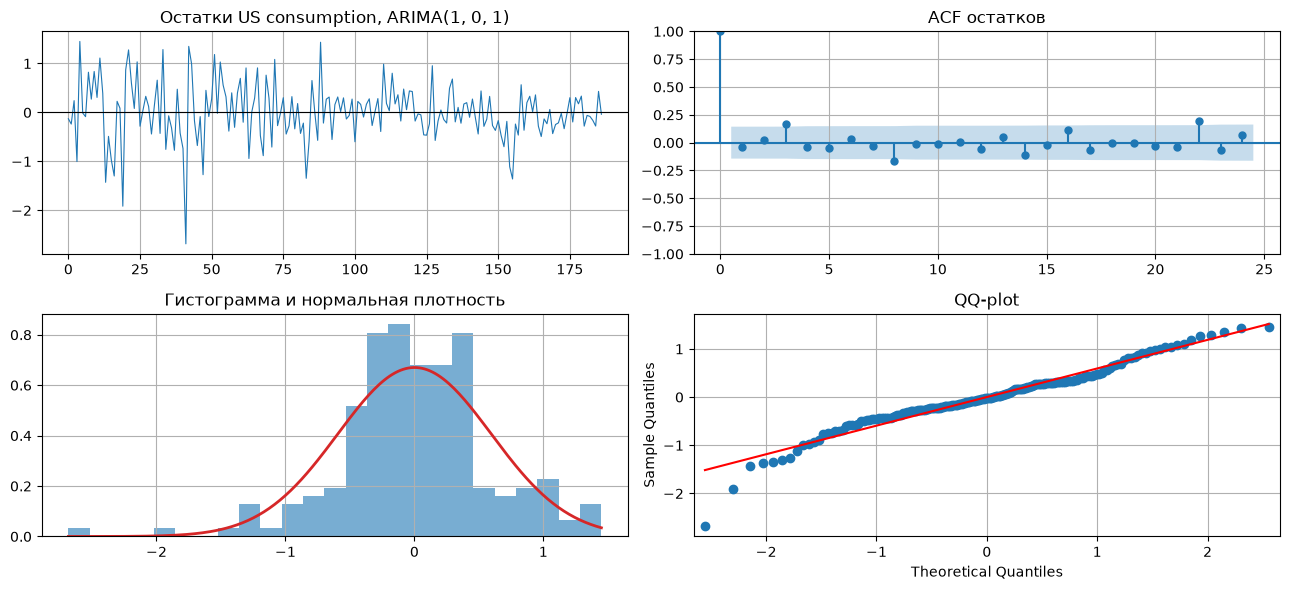

Ljung-Box (model_df = p + q = 2):
   лаг   8:  Q = 12.30,  p = 0.0556  -> автокорреляции не видно
   лаг  16:  Q = 18.55,  p = 0.1827  -> автокорреляции не видно
Жарк-Бера: JB = 47.20, p = 0.0000 -> нормальность отвергается
среднее остатков: 0.00100


In [24]:
def residual_report(res, name="", lags=(10,), alpha=0.05):
    """Панель диагностики остатков: график, ACF, QQ + Ljung-Box и Жарк-Бера."""
    resid = pd.Series(np.asarray(res.resid)).iloc[res.loglikelihood_burn:]
    p, d, q = res.model.order
    m_df = p + q

    fig, axes = plt.subplots(2, 2, figsize=(13, 6))
    axes[0, 0].plot(resid.to_numpy(), lw=0.8)
    axes[0, 0].axhline(0, color="k", lw=0.8)
    axes[0, 0].set_title(f"Остатки {name} ARIMA{(p, d, q)}")

    plot_acf(resid, lags=min(24, len(resid) // 2 - 1), ax=axes[0, 1], title="ACF остатков")

    axes[1, 0].hist(resid, bins=25, density=True, alpha=0.6)
    xs = np.linspace(resid.min(), resid.max(), 200)
    axes[1, 0].plot(xs, stats.norm.pdf(xs, resid.mean(), resid.std()), lw=2, color="tab:red")
    axes[1, 0].set_title("Гистограмма и нормальная плотность")

    sm.qqplot(resid, line="s", ax=axes[1, 1])
    axes[1, 1].set_title("QQ-plot")
    fig.tight_layout()
    plt.show()

    lb = acorr_ljungbox(resid, lags=list(lags), model_df=m_df)
    jb_stat, jb_p = stats.jarque_bera(resid)

    print(f"Ljung-Box (model_df = p + q = {m_df}):")
    for lag in lags:
        pv = lb.loc[lag, "lb_pvalue"]
        verdict = "остатки НЕ белый шум" if pv < alpha else "автокорреляции не видно"
        print(f"   лаг {lag:>3}:  Q = {lb.loc[lag, 'lb_stat']:.2f},  p = {pv:.4f}  -> {verdict}")
    print(f"Жарк-Бера: JB = {jb_stat:.2f}, p = {jb_p:.4f} -> "
          f"{'нормальность отвергается' if jb_p < alpha else 'нормальность не отвергается'}")
    print(f"среднее остатков: {resid.mean():.5f}")


residual_report(res_check, name="US consumption,", lags=(8, 16))

## 7.3. Как это читать

Разберём панель по частям:

* **ACF остатков** — главный график. Один-два столбика вне полосы на далёких
  лагах — норма (раздел 3.3). Систематический узор — не норма;
* **Ljung–Box** — формальная версия того же. $p < 0.05$ означает «в остатках
  осталась автокорреляция» $\Rightarrow$ возврат к шагу 4;
* **гистограмма и QQ-plot** — про нормальность. Отклонения на концах QQ-plot
  означают тяжёлые хвосты;
* **Жарк–Бера** — формальная проверка нормальности.

🔑 **Важная асимметрия: автокорреляция и нормальность — разного веса
проблемы.**

* Автокорреляция в остатках означает, что модель **не забрала всю
  предсказуемую информацию**. Это чинится — возврат к шагу 4.
* Ненормальность остатков **не портит точечный прогноз** (он остаётся
  наилучшей линейной оценкой), но портит **интервал**, потому что формулы из
  ноутбука `02` опираются на нормальность. Лечится не сменой $(p, q)$, а
  бутстрепом или конформными интервалами (ноутбук `02`, раздел 8).

Посмотрим на модель с явно плохими остатками — намеренно подгоним ARIMA(0,0,0)
(то есть «ряд = константа + шум») к ряду, у которого структура есть.

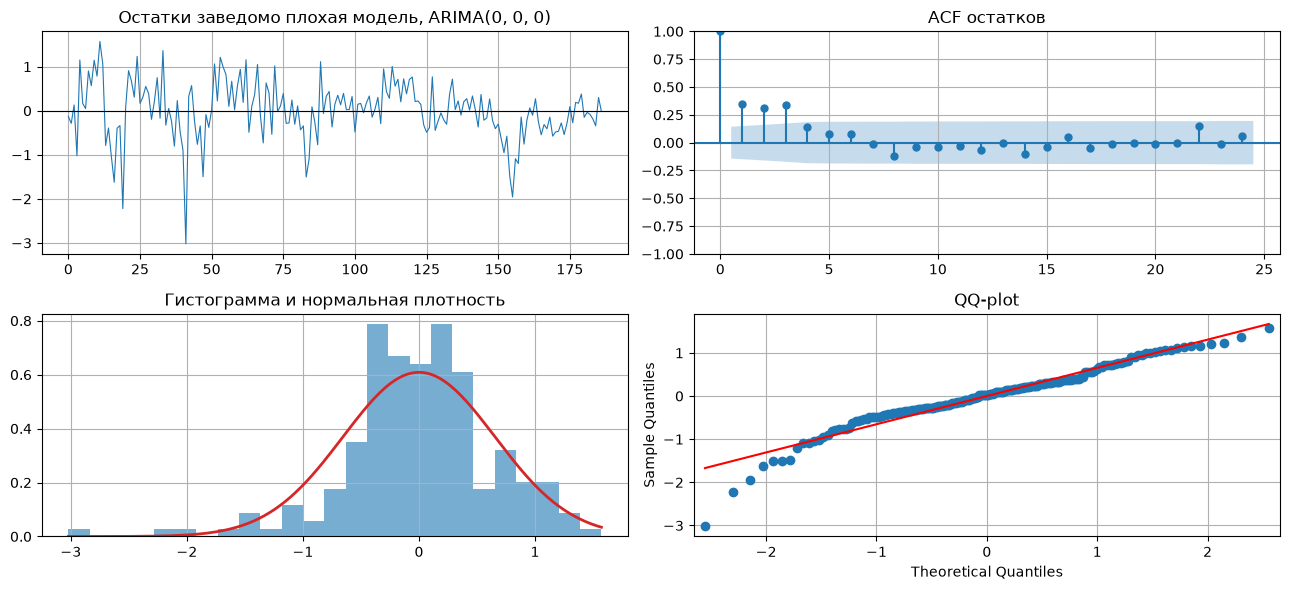

Ljung-Box (model_df = p + q = 0):
   лаг   8:  Q = 72.48,  p = 0.0000  -> остатки НЕ белый шум
   лаг  16:  Q = 77.15,  p = 0.0000  -> остатки НЕ белый шум
Жарк-Бера: JB = 72.62, p = 0.0000 -> нормальность отвергается
среднее остатков: 0.00000


In [25]:
residual_report(ARIMA(consumption, order=(0, 0, 0), trend="c").fit(),
                name="заведомо плохая модель,", lags=(8, 16))

ACF остатков показывает явный столбик на первых лагах, Ljung–Box уверенно
отвергает белый шум. Именно так выглядит сигнал «вернитесь к шагу 4».

---
# 8. Кейс: четыре модели, четыре порядка, один AICc

Теперь главный урок ноутбука, ради которого всё писалось. Пройдём шаг 5
честно и посмотрим, что получится.

Ряд — US consumption. Из семинара 1 мы знаем: он стационарен, $d = 0$
(KPSS не отвергает стационарность). Проверим и посмотрим на коррелограмму.

KPSS на уровне: p-value = 0.100 -> d = 0


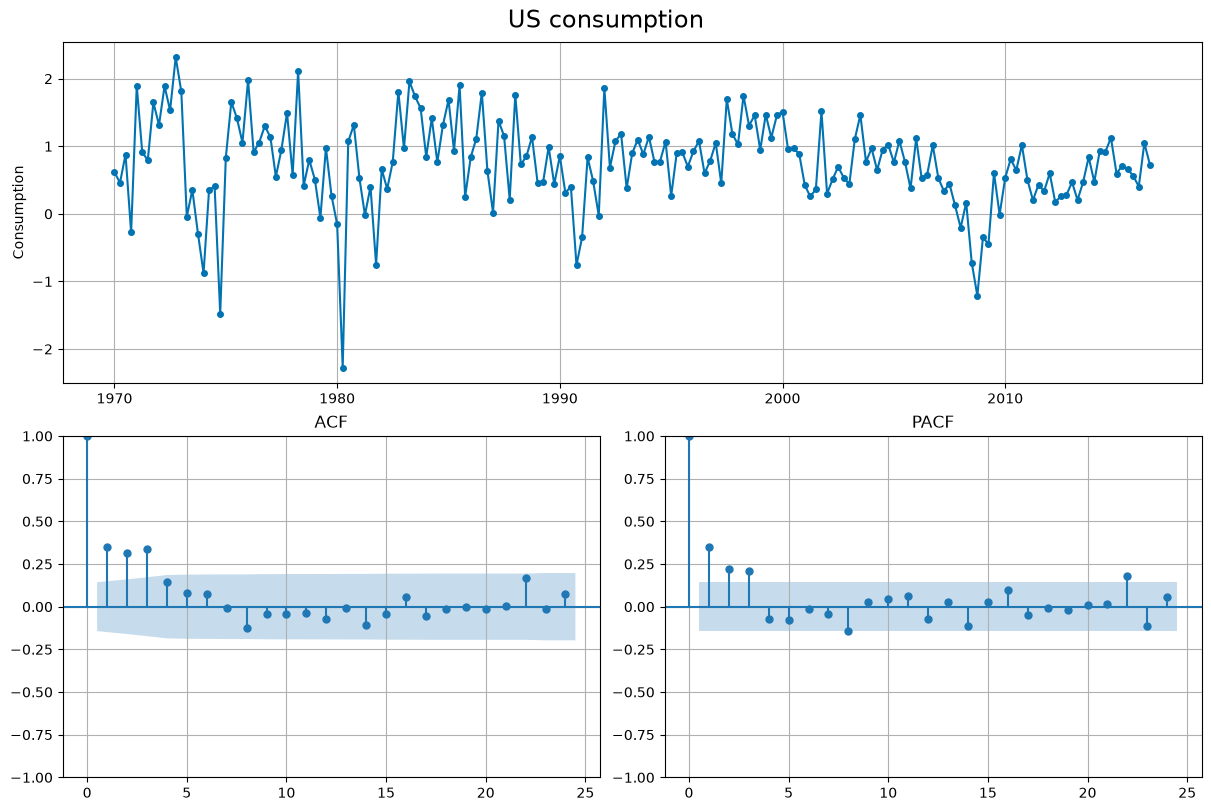

<Figure size 1300x600 with 0 Axes>

In [26]:
print(f"KPSS на уровне: p-value = {kpss(consumption, regression='c', nlags='auto')[1]:.3f} -> d = 0")
tsdisplay(consumption, lags=24, title="US consumption")
plt.show()

ACF затухает, PACF тоже затухает (со всплеском на лагах 1–3). Ни то, ни
другое не обрывается $\Rightarrow$ по правилам 6–7 это ARMA, и порядок по
картинке не читается. Значит, придётся перебирать.

Возьмём **четыре разных способа** выбрать модель:

1. «глазами»: PACF гаснет после третьего лага $\Rightarrow$ ARIMA(3,0,0);
2. «глазами наоборот»: ACF выглядит так, будто гаснет к лагу 3
   $\Rightarrow$ ARIMA(0,0,3);
3. пошаговый автоподбор `AutoARIMA(stepwise=True)`;
4. полный перебор по сетке $p, q \le 4$ с минимумом AICc.

In [27]:
# 3) пошаговый автоподбор
auto_step = AutoARIMA(season_length=1).fit(consumption.to_numpy(dtype=np.float64))
print("AutoARIMA (stepwise):", arima_string(auto_step.model_).strip())
print("его AICc:", round(float(auto_step.model_["aicc"]), 2))

AutoARIMA (stepwise): ARIMA(1,0,3) with non-zero mean
его AICc: 342.08


In [28]:
# 4) полный перебор (сетка уже посчитана в разделе 5.3)
best_full = grid_us.sort_values("AICc").iloc[0]
print("полный перебор:", best_full["order"], " AICc =", round(best_full["AICc"], 2))

полный перебор: (3, 0, 0)  AICc = 340.67


In [29]:
CANDIDATES_US = [(3, 0, 0), (0, 0, 3), (1, 0, 3), (2, 0, 2)]

rows = []
fitted = {}
for order in CANDIDATES_US:
    res = ARIMA(consumption, order=order, trend="c").fit()
    fitted[order] = res
    lb_p = acorr_ljungbox(res.resid, lags=[12], model_df=order[0] + order[2]).loc[12, "lb_pvalue"]
    rows.append({
        "модель": f"ARIMA{order}",
        "число параметров": len(res.params),
        "AICc": aicc(res),
        "BIC": res.bic,
        "Ljung-Box p (лаг 12)": lb_p,
        "sigma^2": float(np.asarray(res.params)[res.param_names.index("sigma2")]),
    })

table_case = pd.DataFrame(rows)
table_case["ΔAICc"] = table_case["AICc"] - table_case["AICc"].min()
table_case.round(3)

,модель,число параметров,AICc,BIC,Ljung-Box p (лаг 12),sigma^2,ΔAICc
0,"ARIMA(3, 0, 0)",5,340.671,356.495,0.575,0.342,0.000
1,"ARIMA(0, 0, 3)",5,343.090,358.914,0.395,0.346,2.419
2,"ARIMA(1, 0, 3)",6,342.080,361.000,0.565,0.341,1.409
3,"ARIMA(2, 0, 2)",6,342.751,361.671,0.511,0.342,2.080


Смотрим на таблицу и осознаём:

* четыре модели с **совершенно разной структурой** — чистая AR(3), чистая
  MA(3), смешанная (1,3) и смешанная (2,2);
* их AICc укладываются в интервал шириной около 2 единиц — то есть по
  правилу 17 они **неразличимы**;
* у всех остатки проходят Ljung–Box;
* оценки $\sigma^2$ практически одинаковые.

Сравним их прогнозы на одном графике.

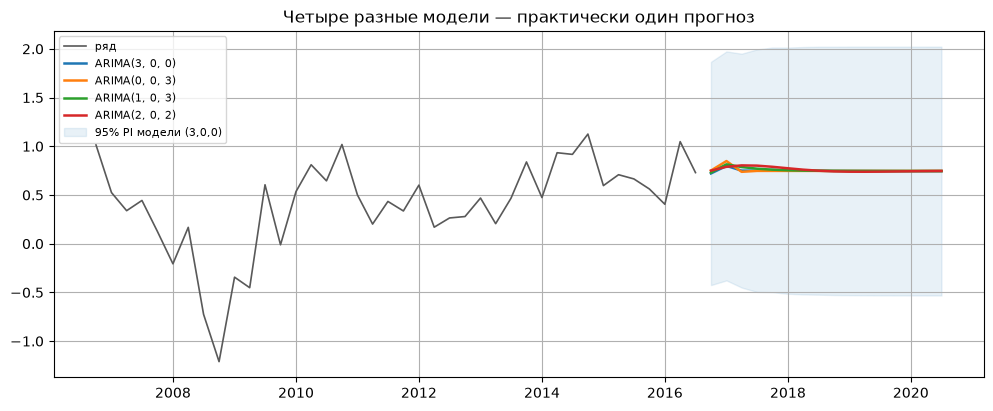

максимальный разброс точечных прогнозов между моделями: 0.066
ширина 95% интервала модели (3,0,0) на h=1: 2.2921


In [30]:
H = 16
fig, ax = plt.subplots(figsize=(12, 4.5))
hist = consumption.iloc[-40:]
ax.plot(hist.index, hist.to_numpy(), color="0.35", lw=1.2, label="ряд")

future = pd.date_range(consumption.index[-1], periods=H + 1, freq="QS")[1:]
for order, res in fitted.items():
    fc = res.get_forecast(H)
    ax.plot(future, np.asarray(fc.predicted_mean), lw=1.8, label=f"ARIMA{order}")

ci = np.asarray(fitted[(3, 0, 0)].get_forecast(H).conf_int())
ax.fill_between(future, ci[:, 0], ci[:, 1], color="tab:blue", alpha=0.10,
                label="95% PI модели (3,0,0)")
ax.set_title("Четыре разные модели — практически один прогноз")
ax.legend(fontsize=8)
plt.show()

spread = pd.DataFrame(
    {f"ARIMA{o}": np.asarray(r.get_forecast(H).predicted_mean) for o, r in fitted.items()},
    index=pd.Index(range(1, H + 1), name="h"),
)
print("максимальный разброс точечных прогнозов между моделями:",
      round(float((spread.max(axis=1) - spread.min(axis=1)).max()), 4))
print("ширина 95% интервала модели (3,0,0) на h=1:", round(float(ci[0, 1] - ci[0, 0]), 4))

🔑 **Главный вывод кейса.** Разброс между четырьмя «разными» моделями
примерно на порядок меньше ширины интервала прогноза любой из них. То есть
**выбор между ними лежит внутри собственной погрешности прогноза** — спор
о том, «(3,0,0) или (1,0,3)», не имеет практического содержания.

Что из этого следует практически:

* не тратьте время на вылавливание последней десятой доли AICc;
* если несколько моделей неразличимы — берите самую простую или **усредните
  их прогнозы** (комбинирование почти всегда не хуже лучшей из них);
* зато **разница между «любой разумной ARMA» и «неверным $d$»** —
  принципиальна, потому что $d$ определяет форму прогноза и рост интервала
  (ноутбук `02`, разделы 6–7).

🔍 Заметьте ещё, что пошаговый `AutoARIMA` нашёл (1,0,3) с AICc 342.08, а
полный перебор — (3,0,0) с AICc 340.67. Пошаговый обход **не гарантирует**
глобального минимума: он проверяет лишь соседей текущей модели. Как именно
он ходит по сетке и почему это оправдано — тема ноутбука `05`.

---
# 9. Сквозной кейс: от графика до метрики на тесте

Финал. Проходим все семь шагов подряд, без пропусков, и доводим дело до
числа, которого нам не хватало весь семинар — **ошибки на отложенной
выборке**.

Ряд тот же, US consumption. Отложим последние 16 кварталов (4 года) под
тест и **больше не будем на них смотреть** до самого конца.

In [31]:
H_TEST = 16
train, test = consumption.iloc[:-H_TEST], consumption.iloc[-H_TEST:]

print(f"обучение: {train.index[0].date()} — {train.index[-1].date()}, {len(train)} кварталов")
print(f"тест:     {test.index[0].date()} — {test.index[-1].date()}, {len(test)} кварталов")

обучение: 1970-01-01 — 2012-07-01, 171 кварталов
тест:     2012-10-01 — 2016-07-01, 16 кварталов


## Шаг 1. График

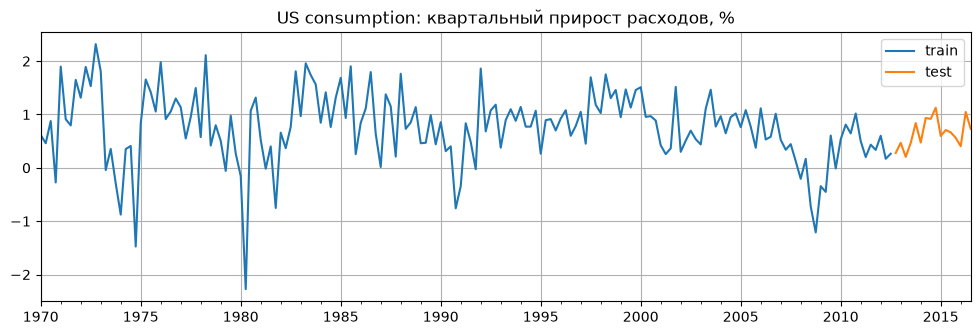

count    171.000
mean       0.755
std        0.680
min       -2.274
25%        0.414
50%        0.795
75%        1.114
max        2.318


In [32]:
fig, ax = plt.subplots(figsize=(12, 3.5))
train.plot(ax=ax, label="train")
test.plot(ax=ax, label="test", color="tab:orange")
ax.set_title("US consumption: квартальный прирост расходов, %")
ax.legend()
plt.show()

print(train.describe().round(3).to_string())

Что видно: уровень стабилен, ярко выраженного тренда нет. Есть один резкий
провал — кризис 2008 года. Дисперсия на глаз примерно постоянная, разве что
ранние годы чуть беспокойнее.

## Шаг 2. Бокс–Кокс?

**Нет.** И причина не в статистике, а в арифметике: в ряде есть
**отрицательные значения** (это прирост в процентах, он бывает и
отрицательным), а преобразование Бокса–Кокса определено только для
положительных данных.

In [33]:
print("минимум ряда:", round(float(train.min()), 3), "-> Бокс-Кокс неприменим")

минимум ряда: -2.274 -> Бокс-Кокс неприменим


🔍 Это частая ситуация с любыми «приростами», «разностями» и «доходностями».
Формально можно сдвинуть ряд на константу, но обычно это не нужно: если
дисперсия стабильна, шаг 2 просто пропускается.

## Шаг 3. Выбор $d$

In [34]:
from statsmodels.tsa.stattools import adfuller

adf_stat, adf_p = adfuller(train, autolag="AIC")[:2]
kpss_stat, kpss_p = kpss(train, regression="c", nlags="auto")[:2]

print(f"ADF:  p-value = {adf_p:.4f} -> {'единичного корня нет' if adf_p < 0.05 else 'есть единичный корень'}")
print(f"KPSS: p-value = {kpss_p:.4f} -> {'нестационарен' if kpss_p < 0.05 else 'стационарен'}")
print("\nоба теста согласны: d = 0")

ADF:  p-value = 0.0005 -> единичного корня нет
KPSS: p-value = 0.1000 -> стационарен

оба теста согласны: d = 0


Клетка «ADF: нет единичного корня» × «KPSS: стационарен» из таблицы 2×2
ноутбука `1.02` — самый однозначный из четырёх исходов.

## Шаг 4. ACF и PACF

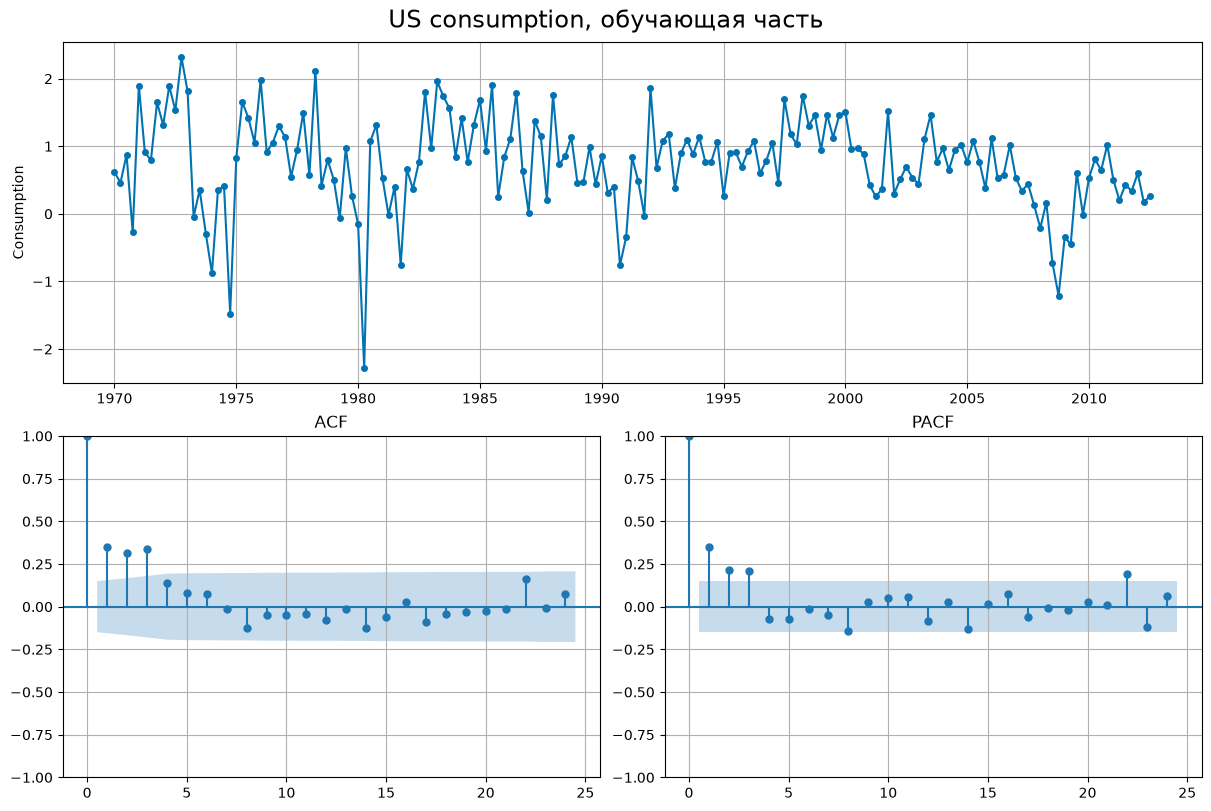

<Figure size 1300x600 with 0 Axes>

In [35]:
tsdisplay(train, lags=24, title="US consumption, обучающая часть")
plt.show()

Как и на полном ряду: обе функции затухают, обрыва нет. Стартовые кандидаты —
ARMA небольшого порядка. Возьмём для перебора $p, q \le 4$.

## Шаг 5. Перебор по AICc

In [36]:
rows = []
for p in range(5):
    for q in range(5):
        rows.append(fit_report(train, (p, 0, q), trend="c"))

grid_train = pd.DataFrame(rows).sort_values("AICc")
grid_train.head(5)[["order", "k", "AIC", "AICc", "BIC"]].round(2)

,order,k,AIC,AICc,BIC
15,"(3, 0, 0)",5,325.00,325.36,340.70
20,"(4, 0, 0)",6,326.14,326.66,344.99
8,"(1, 0, 3)",6,326.38,326.89,345.23
16,"(3, 0, 1)",6,326.49,327.00,345.34
18,"(3, 0, 3)",8,326.25,327.13,351.38


,order,k,AIC,AICc,BIC
15,"(3, 0, 0)",5,325.00,325.36,340.70
20,"(4, 0, 0)",6,326.14,326.66,344.99
8,"(1, 0, 3)",6,326.38,326.89,345.23
16,"(3, 0, 1)",6,326.49,327.00,345.34
18,"(3, 0, 3)",8,326.25,327.13,351.38


In [37]:
best_order = eval(grid_train.iloc[0]["order"])
print("лучшая по AICc на обучающей части:", best_order)

res_final = ARIMA(train, order=best_order, trend="c").fit()
print(res_final.summary().tables[1])

лучшая по AICc на обучающей части: (3, 0, 0)
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.7457      0.123      6.051      0.000       0.504       0.987
ar.L1          0.2282      0.062      3.670      0.000       0.106       0.350
ar.L2          0.1583      0.064      2.483      0.013       0.033       0.283
ar.L3          0.2044      0.072      2.830      0.005       0.063       0.346
sigma2         0.3687      0.029     12.828      0.000       0.312       0.425


## Шаг 6. Остатки

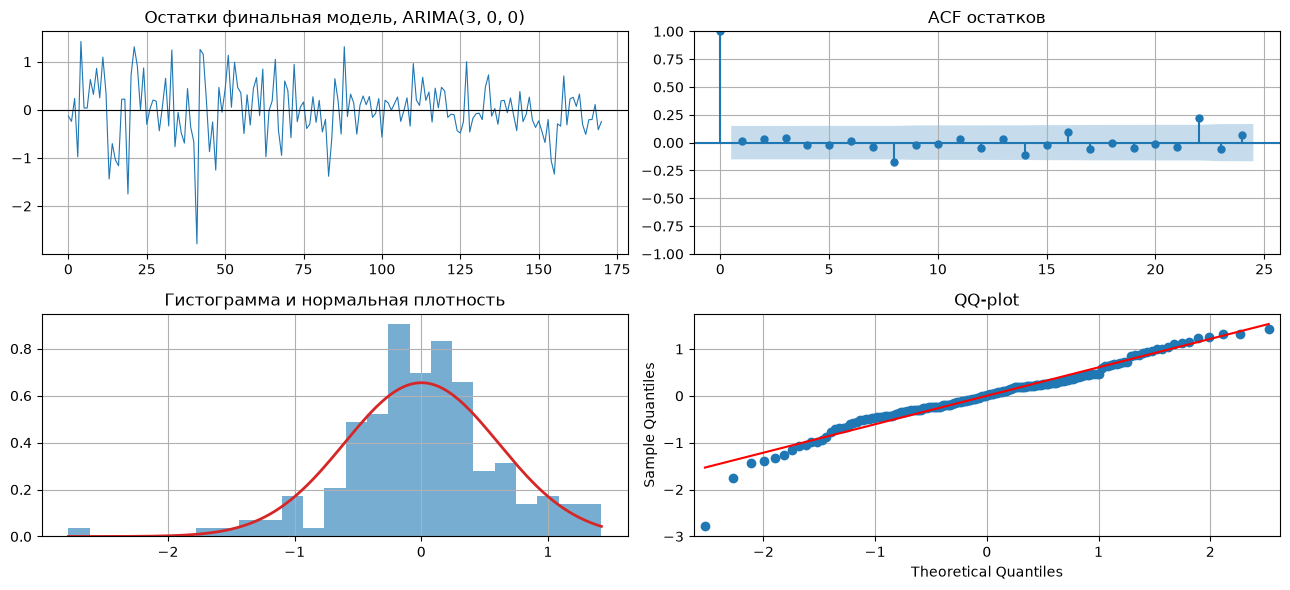

Ljung-Box (model_df = p + q = 3):
   лаг   8:  Q = 6.25,  p = 0.2823  -> автокорреляции не видно
   лаг  16:  Q = 11.48,  p = 0.5703  -> автокорреляции не видно
Жарк-Бера: JB = 45.79, p = 0.0000 -> нормальность отвергается
среднее остатков: 0.00110


In [38]:
residual_report(res_final, name="финальная модель,", lags=(8, 16))

Автокорреляции в остатках нет — Ljung–Box не отвергает белый шум. Хвосты
распределения тяжелее нормальных (это видно на QQ-plot, и Жарк–Бера это
подтверждает) — типично для макроэкономики с её кризисами. Как обсуждали в
разделе 7.3, на точечный прогноз это не влияет, а вот интервалы будут
оптимистичны.

Останавливаемся: возвращаться к шагу 4 не нужно.

## Уравнение модели с числами

Соберём то, ради чего всё делалось: **выписанное уравнение**. Модель —
AR($p$) с константой, значит

$$ y_t = c + \varphi_1 y_{t-1} + \dots + \varphi_p y_{t-p} + \varepsilon_t, $$

где $c = \mu\,(1 - \sum \varphi_i)$, а `const` в `summary()` — это $\mu$
(ноутбук `01`, раздел 8).

In [39]:
mu = res_final.params["const"]
phi = res_final.arparams
theta = res_final.maparams
sigma2 = float(np.asarray(res_final.params)[res_final.param_names.index("sigma2")])
c = mu * (1 - phi.sum())

equation = f"y_t = {c:+.4f}"
equation += "".join(f" {ph:+.4f}·y_(t-{i + 1})" for i, ph in enumerate(phi))
equation += " + eps_t"
equation += "".join(f" {th:+.4f}·eps_(t-{i + 1})" for i, th in enumerate(theta))

print(equation)
print(f"\nгде eps_t ~ N(0, {sigma2:.4f}),  sigma = {np.sqrt(sigma2):.4f}")
print(f"среднее ряда по модели: mu = {mu:.4f}  (выборочное среднее train: {train.mean():.4f})")
print(f"сумма phi = {phi.sum():.4f}  -> далеко от 1, правило 9 не нарушено")

y_t = +0.3050 +0.2282·y_(t-1) +0.1583·y_(t-2) +0.2044·y_(t-3) + eps_t

где eps_t ~ N(0, 0.3687),  sigma = 0.6072
среднее ряда по модели: mu = 0.7457  (выборочное среднее train: 0.7554)
сумма phi = 0.5910  -> далеко от 1, правило 9 не нарушено


Вот теперь модель — не объект `res_final`, а формула, которую можно
посчитать на бумаге. Проверим её на одном шаге: подставим последние
наблюдения обучающей выборки.

In [40]:
y_train = train.to_numpy()
manual_1 = c + float(np.dot(phi, y_train[-len(phi):][::-1]))

print(f"по формуле руками: {manual_1:.6f}")
print(f"get_forecast(1):   {float(res_final.get_forecast(1).predicted_mean.iloc[0]):.6f}")

по формуле руками: 0.515024
get_forecast(1):   0.515024


## Шаг 7. Прогноз и метрика на тесте

Строим прогноз на 16 кварталов и сравниваем с отложенными данными. Кроме
самой модели считаем два **бенчмарка** — без них число RMSE не значит ничего:

* **наивный прогноз**: «дальше как в последнем наблюдении»;
* **среднее**: «дальше как в среднем по обучающей выборке».

И добавляем конкурентов из раздела 8 — модели, неразличимые по AICc.

In [41]:
def metrics(actual, pred):
    actual, pred = np.asarray(actual, dtype=float), np.asarray(pred, dtype=float)
    err = actual - pred
    return {
        "RMSE": float(np.sqrt((err ** 2).mean())),
        "MAE": float(np.abs(err).mean()),
    }


scores = {}
forecasts = {}

for order in [best_order, (3, 0, 0), (2, 0, 2), (1, 0, 1)]:
    res = ARIMA(train, order=order, trend="c").fit()
    fc = np.asarray(res.get_forecast(H_TEST).predicted_mean)
    forecasts[f"ARIMA{order}"] = fc
    scores[f"ARIMA{order}"] = metrics(test, fc)

scores["наивный"] = metrics(test, np.repeat(train.iloc[-1], H_TEST))
scores["среднее train"] = metrics(test, np.repeat(train.mean(), H_TEST))
forecasts["наивный"] = np.repeat(train.iloc[-1], H_TEST)
forecasts["среднее train"] = np.repeat(train.mean(), H_TEST)

pd.DataFrame(scores).T.sort_values("RMSE").round(4)

,RMSE,MAE
"ARIMA(3, 0, 0)",0.2261,0.1916
"ARIMA(1, 0, 1)",0.2282,0.1952
"ARIMA(2, 0, 2)",0.2299,0.1993
среднее train,0.2805,0.2398
наивный,0.4666,0.3945


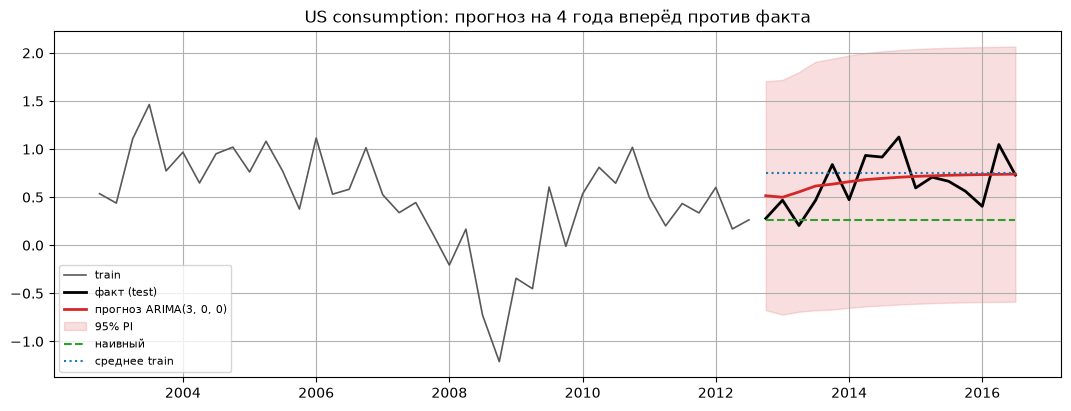

доля фактических значений внутри 95% PI: 100%


In [42]:
fc_best = res_final.get_forecast(H_TEST)
ci = np.asarray(fc_best.conf_int())

fig, ax = plt.subplots(figsize=(13, 4.5))
tail = train.iloc[-40:]
ax.plot(tail.index, tail.to_numpy(), color="0.35", lw=1.2, label="train")
ax.plot(test.index, test.to_numpy(), color="k", lw=2, label="факт (test)")
ax.plot(test.index, np.asarray(fc_best.predicted_mean), color="tab:red", lw=2,
        label=f"прогноз ARIMA{best_order}")
ax.fill_between(test.index, ci[:, 0], ci[:, 1], color="tab:red", alpha=0.15, label="95% PI")
ax.plot(test.index, forecasts["наивный"], ls="--", color="tab:green", label="наивный")
ax.plot(test.index, forecasts["среднее train"], ls=":", color="tab:blue", label="среднее train")
ax.set_title("US consumption: прогноз на 4 года вперёд против факта")
ax.legend(fontsize=8)
plt.show()

inside = ((test.to_numpy() >= ci[:, 0]) & (test.to_numpy() <= ci[:, 1])).mean()
print(f"доля фактических значений внутри 95% PI: {inside:.0%}")

## Что говорят числа

* **Модель уверенно бьёт наивный прогноз** — примерно вдвое по RMSE. Это
  ожидаемо: наивный прогноз хорош для рядов со стохастическим трендом, а наш
  ряд стационарен, и «завтра как сегодня» для него плохая идея.
* **Выигрыш у бенчмарка «среднее» гораздо скромнее.** И это честный
  результат, а не провал: у стационарного ряда долгосрочный прогноз любой
  ARMA-модели **сходится к среднему** (ноутбук `02`, раздел 3). На горизонте
  16 кварталов модель почти всюду уже равна $\hat\mu$, поэтому обогнать
  среднее она может только на первых нескольких шагах.
* **Все ARIMA-кандидаты дали почти одинаковый RMSE** — разница в третьем
  знаке. Ровно то, что обещал раздел 8: неразличимые по AICc модели
  неразличимы и на тесте.

🔑 **Важная методическая мысль про горизонт.** Сравнение на $h = 16$ для
стационарного ряда почти не отличает модели — все они там равны $\hat\mu$.
Если нужно сравнивать модели по прогнозной силе, делать это надо на том
горизонте, который вам реально нужен, и лучше по **кросс-валидации со
скользящим началом**, а не по одному разбиению (ноутбук `02`, раздел 8.2, и
ноутбук `05`).

Проверим эту мысль: посчитаем RMSE отдельно по горизонтам.

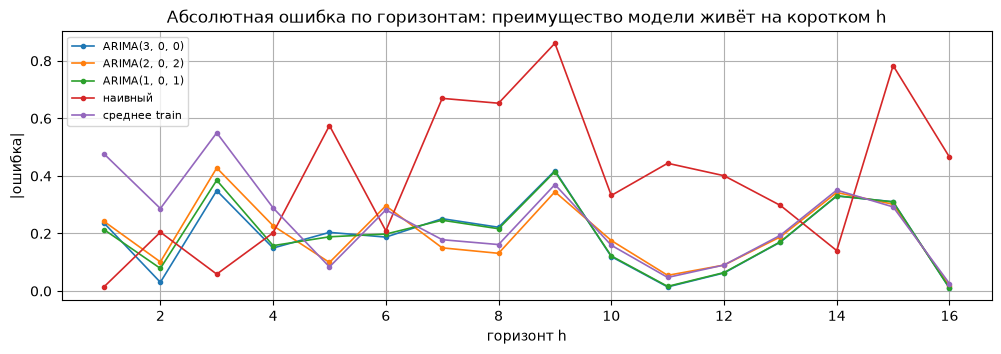

,"ARIMA(3, 0, 0)","ARIMA(2, 0, 2)","ARIMA(1, 0, 1)",наивный,среднее train
горизонт h,,,,,
1,0.236,0.242,0.213,0.015,0.477
2,0.030,0.101,0.079,0.204,0.287
3,0.349,0.428,0.385,0.059,0.550
4,0.149,0.227,0.158,0.202,0.289
5,0.204,0.099,0.188,0.575,0.084
6,0.187,0.296,0.198,0.209,0.282


In [43]:
by_h = pd.DataFrame({
    name: np.abs(test.to_numpy() - np.asarray(fc))
    for name, fc in forecasts.items()
}, index=pd.Index(range(1, H_TEST + 1), name="горизонт h"))

fig, ax = plt.subplots(figsize=(12, 3.5))
for name in by_h.columns:
    ax.plot(by_h.index, by_h[name], marker="o", ms=3, lw=1.2, label=name)
ax.set_ylabel("|ошибка|"); ax.set_xlabel("горизонт h")
ax.set_title("Абсолютная ошибка по горизонтам: преимущество модели живёт на коротком h")
ax.legend(fontsize=8)
plt.show()

by_h.iloc[:6].round(3)

На первых шагах модель заметно точнее среднего, дальше кривые сливаются.
Это и есть содержательный ответ на вопрос «зачем нам ARIMA на стационарном
ряду»: **ради короткого горизонта.**

---
# Итоги

* **Идентификация порядка — это процедура из семи шагов**, а не угадывание:
  график → Бокс–Кокс → разности → ACF/PACF → AICc → остатки → прогноз.
  Шаг 6 замкнут на шаг 4 — это цикл (раздел 1).
* **Разделение труда жёсткое:** $d$ выбирается тестами, $(p, q)$ — по AICc,
  финальное сравнение разнородных моделей — по ошибке на тесте. AICc **не
  умеет** сравнивать модели с разным $d$ (раздел 5.4).
* **Правила 6–7:** обрыв ACF на лаге $q$ ⇒ MA($q$); обрыв PACF на лаге $p$ ⇒
  AR($p$); ничего не обрывается ⇒ ARMA, и порядок по картинке не читается
  (раздел 2).
* **PACF — это коэффициент при последнем лаге в регрессии на $k$ лагов**,
  то есть связь без посредников. Считается циклом OLS в шесть строк
  (раздел 3).
* **Границы $\pm 1.96/\sqrt{n}$ — не приговор:** на 36 лагах белого шума
  один-два столбика вылезают наружу случайно (раздел 3.3).
* **AIC / AICc / BIC различаются только силой штрафа.** AICc — рабочий
  выбор, BIC систематически выбирает модель проще (раздел 5).
* **Три предупреждения:** близкие корни $\varphi(L)$ и $\theta(L)$ ⇒ порядок
  завышен (правило 8); $\sum\varphi_i \approx 1$ ⇒ нужно увеличить $d$, а не
  $p$ (правила 9–11); разница в 1–2 AICc ничего не значит (правило 17)
  (раздел 6).
* **Ljung–Box на остатках модели нужно звать с `model_df = p + q`**, иначе
  p-value завышается и плохая модель проходит проверку (раздел 7.1).
* **Автокорреляция остатков — чинится сменой порядка; ненормальность —
  не чинится и бьёт только по интервалам** (раздел 7.3).
* **Правильный порядок не единственный.** Четыре модели с разной структурой
  дали AICc в пределах двух единиц, а расхождение их прогнозов оказалось на
  порядок меньше ширины интервала (раздел 8).
* **Сквозной кейс доведён до числа:** модель бьёт наивный прогноз вдвое,
  среднее — скромно и только на коротком горизонте (раздел 9).

## Шпаргалка по идентификации

| Что видим | Что делаем |
|---|---|
| ACF затухает медленно, вся положительная | разность: $d \mathrel{+}= 1$ |
| $\rho_1 \le -0.5$, «пила» в ACF | передифференцировали, $d \mathrel{-}= 1$ |
| ACF обрывается на лаге $q$, PACF затухает | MA($q$) |
| PACF обрывается на лаге $p$, ACF затухает | AR($p$) |
| обе затухают | ARMA, перебор по AICc |
| огромные se, близкие корни AR и MA | сократить $p$ и $q$ |
| $\sum\varphi_i \approx 1$ | увеличить $d$ |
| ACF остатков со структурой, Ljung–Box отвергает | вернуться к шагу 4 |
| тяжёлые хвосты остатков | точечный прогноз в порядке, чинить интервалы |


---
## Ответы к разделу 4

Сначала запишите свои ответы, потом разворачивайте.

<details>
<summary><b>Показать истинные порядки</b></summary>

| Ряд | Истина | Как это было видно |
|---|---|---|
| **A** | ARMA(1,0,0) | ACF затухает плавно, PACF обрывается после лага 1 |
| **B** | ARMA(0,0,2) | ACF обрывается после лага 2, PACF затухает |
| **C** | ARMA(1,0,1) | не обрывается ничего — смешанная модель |
| **D** | ARIMA(0,1,1) | ряд блуждает, ACF затухает крайне медленно ⇒ сначала разность |
| **E** | ARMA(2,0,0) | ACF — затухающая волна (комплексные корни), PACF обрыв на лаге 2 |
| **F** | ARMA(0,0,0) | белый шум: всё внутри полосы (кроме случайных выбросов) |

</details>

In [44]:
pd.DataFrame({
    "истина (p, d, q)": {k: str(v) for k, v in quiz_truth.items()},
    "AutoARIMA": auto_answers,
})

,"истина (p, d, q)",AutoARIMA
A,"(1, 0, 0)","ARIMA(1,1,1) with drift"
B,"(0, 0, 2)","ARIMA(0,1,0)"
C,"(1, 0, 1)","ARIMA(4,0,1) with non-zero mean"
D,"(0, 1, 1)","ARIMA(0,1,1)"
E,"(2, 0, 0)","ARIMA(2,0,0) with zero mean"
F,"(0, 0, 0)","ARIMA(0,0,0) with zero mean"


🔍 Обратите внимание: даже на **симулированных** данных, где истинный
порядок существует и известен, автоподбор угадывает его не всегда. Это не
недостаток алгоритма — это тот же эффект из раздела 6.3: на конечной
выборке несколько моделей описывают данные одинаково хорошо.